# Finding, mapping and fetching granules with `hyperproc.archive`

Every other notebook in this folder starts from a file that is already on disk. This one
starts from **a place and a date**, and ends with a granule you can hand straight to
`hp.open`.

`hp.search` is one function over three archives. Which archive answers is decided by the
`(sensor, level)` pair you ask for, not by which function you call, so the rest of a
workflow never has to know.

| Archive | Carries | Searching | Downloading needs |
|---|---|---|---|
| **NASA CMR** (via `earthaccess`) | EMIT, PACE, AVIRIS-3, AVIRIS-5 | anonymous | a free Earthdata login |
| **NEON Data API v0** | NEON AOP flightlines (DP1.30006.001) | anonymous | a NEON API token, **required since June 2026** |
| **DLR EOC Geoservice STAC** | EnMAP L1B/L1C/L2A, DESIS L2A | anonymous | a free DLR EOC account |

**Searching all three needs no account at all.** Only the bytes are gated, and each
backend raises with its own registration address rather than returning an empty list or a
bare `403`.

## How the notebook is laid out

**Part 1 - the reference.** Every function, every parameter, with one worked example.

**Part 2 - the tour.** All **thirteen** searchable `(sensor, level)` pairs, one after
another, each doing the same three things:

> **search** &rarr; **map the footprints** &rarr; **pick scenes and download them**

They share one area of interest, so the differences you see between them are real
differences between the instruments, not differences between the questions asked.

## Credentials, and where each is read from

You need none of these for Part 1, or for the search and map steps of Part 2.

| Archive | Register at | hyperproc reads |
|---|---|---|
| NASA | <https://urs.earthdata.nasa.gov> | `~/.netrc` (`machine urs.earthdata.nasa.gov`), or `EARTHDATA_USERNAME` / `EARTHDATA_PASSWORD`; `earthaccess` asks once if neither is set |
| NEON | <https://data.neonscience.org/myaccount> | `NEON_TOKEN`, or `token=` on the call |
| DLR — **EnMAP** | <https://www.enmap.org/data_access/> | `ENMAP_USERNAME` / `ENMAP_PASSWORD` |
| DLR — **DESIS** | <https://eoweb.dlr.de/egp/> (EOWEB Geoportal) | `DESIS_USERNAME` / `DESIS_PASSWORD` |

**DLR is two doors, not one.** EnMAP and DESIS files both sit on
`download.geoservice.dlr.de` behind the one single sign-on, but DLR grants access to each
mission separately, so the two accounts need not be the same. `DLR_EOC_USERNAME` /
`DLR_EOC_PASSWORD` still work as a shared fallback for whichever mission has no pair of
its own, and `~/.netrc` (`machine download.geoservice.dlr.de`) is the last resort - it can
hold only one login, since both missions share a host.

## Install

```bash
pip install 'hyperproc[search]'       # search and download
pip install 'hyperproc[search-map]'   # + the interactive map
```

In [27]:
import os
import time
import warnings
from datetime import datetime
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np

import hyperproc as hp

ROOT = Path("/data/fujiang/Hyperspectral_data_processing")
print("hyperproc", hp.__version__)
print("run at   ", datetime.now().strftime("%Y-%m-%d %H:%M"))

hyperproc 0.1.0
run at    2026-10-01 15:48


## Step 0 - the control panel

| Parameter | What it controls |
|---|---|
| `AOI` | the bounding box, `(west, south, east, north)` in degrees. Southern and central California: EMIT and PACE pass over it, EnMAP and DESIS have both imaged it, the AVIRIS-3 and AVIRIS-5 campaigns flew it, and three NEON sites sit inside it. **One box reaches all thirteen collections**, which is the only reason the tour can compare them |
| `TARGETS` | one row per `(sensor, level)`: its own date window and cloud limit. The windows differ because the instruments do - see the table below |
| `COUNT` | how many granules each search may return |
| `DOWNLOAD` | per-collection switch, all on: one scene from each of the thirteen. The eight CMR collections total about 19 GB. A collection you have no credentials for prints what it needs and fetches nothing, so leaving them all on is safe |
| `PICK` | the **order** scenes are considered in: `"smallest"`, `"clearest"` or `"first"` (whatever the archive returned) |
| `TAKE` | **how many** off the top of that order. `1` by default, an integer, or `"all"` for every hit the search returned |
| `MAX_GB` | a ceiling, in gigabytes. A download totalling more than this is refused with the number, whatever `TAKE` says. `10` lets the default through and lets you take two or three EMIT scenes, and stops `TAKE="all"` on anything - all eight EMIT L2A hits are 34.5 GB, all eight AVIRIS-5 are 46 GB, and the whole tour is about 200 GB |

`PICK` and `TAKE` compose: `PICK="clearest", TAKE=3` fetches the three least cloudy.

**Two cases where `PICK` quietly falls back to the archive's own order**, worth knowing
before trusting it: `"smallest"` needs every granule to publish a size, and NEON, EnMAP
and DESIS publish none; `"clearest"` needs a cloud fraction, and the AVIRIS collections
and PACE L1B report none. In both cases the choice degrades to `"first"` rather than
raising.
| `OUT` | where downloads land. Under `tests/output/`, which the repository ignores |

### Why the date windows differ

| Collection | Window | Why |
|---|---|---|
| EMIT | 2023-2025 | still operating; any window works |
| PACE | one month of 2024 | global coverage every 1-2 days, so a month is plenty |
| AVIRIS-3 | 2023-2025 | flies in campaigns, not continuously - an empty month means no flight, not a failure |
| AVIRIS-5 | 2025 | first science flights were 2025 |
| NEON | 2021-2024 | a site is flown once a year at most, in its growing season |
| EnMAP | 2023-2024 | operating since 2022 |
| **DESIS** | **2019-2021** | **the public archive stops at the end of 2021.** Asking for 2023 returns nothing, correctly, and that is the sort of empty result worth being able to tell apart from a broken query |

In [37]:
# ---- where -----------------------------------------------------------------
AOI = (-121.0, 33.5, -115.0, 37.5)          # southern + central California

# ---- what, per collection --------------------------------------------------
# (sensor, level): (date window, cloud limit or None)
TARGETS = {
    ("EMIT",     "L1B"): (("2023-01-01", "2025-12-31"), (0, 40)),
    ("EMIT",     "L2A"): (("2023-01-01", "2025-12-31"), (0, 40)),
    ("PACE",     "L1B"): (("2024-03-01", "2024-03-31"), None),   # see below
    ("PACE",     "L2"):  (("2024-03-01", "2024-03-31"), (0, 60)),
    ("AVIRIS-3", "L1B"): (("2023-01-01", "2025-12-31"), None),
    ("AVIRIS-3", "L2A"): (("2023-01-01", "2025-12-31"), None),
    ("AVIRIS-5", "L1B"): (("2025-01-01", "2025-12-31"), None),
    ("AVIRIS-5", "L2A"): (("2025-01-01", "2025-12-31"), None),
    ("NEON",     "L1"):  (("2021-01",    "2024-12"),    None),
    ("ENMAP",    "L1B"): (("2023-01-01", "2024-12-31"), (0, 30)),
    ("ENMAP",    "L1C"): (("2023-01-01", "2024-12-31"), (0, 30)),
    ("ENMAP",    "L2A"): (("2023-01-01", "2024-12-31"), (0, 30)),
    ("DESIS",    "L2A"): (("2019-01-01", "2021-12-31"), (0, 30)),
}

COUNT  = 8
PICK   = "smallest"      # the order: "smallest" | "clearest" | "first"
TAKE   = 1               # how many off the top; "all" for every hit
MAX_GB = 10              # refuse a download bigger than this, whatever TAKE says

# ---- what to actually fetch ------------------------------------------------
# One scene from every collection. The eight CMR ones come to about 19 GB;
# each is individually under MAX_GB. Set a row False to skip it.
DOWNLOAD = {pair: True for pair in TARGETS}

OUT = ROOT / "tests" / "output" / "archive_demo"
OUT.mkdir(parents=True, exist_ok=True)

print(f"area     {AOI}   ({AOI[2]-AOI[0]:.0f} x {AOI[3]-AOI[1]:.0f} degrees)")
print(f"targets  {len(TARGETS)} collections")
print(f"download {[f'{s} {lv}' for (s, lv), on in DOWNLOAD.items() if on] or 'nothing'}")
print(f"output   {OUT}")

area     (-121.0, 33.5, -115.0, 37.5)   (6 x 4 degrees)
targets  13 collections
download ['EMIT L1B', 'EMIT L2A', 'PACE L1B', 'PACE L2', 'AVIRIS-3 L1B', 'AVIRIS-3 L2A', 'AVIRIS-5 L1B', 'AVIRIS-5 L2A', 'NEON L1', 'ENMAP L1B', 'ENMAP L1C', 'ENMAP L2A', 'DESIS L2A']
output   /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo


### Which credentials this run has

`hp.archive.credentials()` reports what this process could download with. Nothing here is
a secret - only whether one exists.

**The two DLR missions are reported separately**, and that matters: DLR grants EnMAP and
DESIS to different accounts, so one flag for "DLR" reads *found* when you hold only one of
them and then waves the other through to a refusal at download time.
`hp.archive.can_download(sensor, level)` answers the same question for one collection.

In [38]:
def say_credentials():
    '''One line per archive. Nothing here is a secret - only whether one exists.'''
    for who, ok in HAVE.items():
        label = {"cmr": "NASA CMR", "neon": "NEON Data API"}.get(who, f"DLR {who}")
        print(f"  {label:22s} "
              f"{'credentials found' if ok else 'none - search and map still work'}")


HAVE = hp.archive.credentials()
say_credentials()

  NASA CMR               credentials found
  NEON Data API          none - search and map still work
  DLR ENMAP              none - search and map still work
  DLR DESIS              none - search and map still work


### Signing in from inside the notebook, if you have no credentials yet

You do not need this to read the notebook - searching, the maps and every listing below
work without it. Set `SIGN_IN = True` in the next cell and rerun it only when you want to
actually fetch files.

**Nothing you type is echoed or saved.** Passwords and tokens go through `getpass`, which
prints nothing, so they never reach the notebook's stored output. What each archive does
with them differs:

| Archive | What the prompt does | Lasts |
|---|---|---|
| NASA | `earthaccess.login(persist=True)` writes `~/.netrc` itself | **permanently**, once per machine |
| NEON | sets `NEON_TOKEN` in this process | **this kernel only** - export it in your shell to keep it |
| DLR EnMAP | sets `ENMAP_USERNAME` / `ENMAP_PASSWORD` | **this kernel only** |
| DLR DESIS | sets `DESIS_USERNAME` / `DESIS_PASSWORD` | **this kernel only** |

"This kernel only" is worth taking literally: **restart the kernel and the NEON and DLR
logins are gone**, while NASA's survives because `earthaccess` wrote it to `~/.netrc`.
If a download that worked before a restart stops working after one, that is why. Export
them in your shell, or in `~/.bashrc`, to keep them.

Leave any prompt blank to skip that archive. EnMAP and DESIS are asked separately because
DLR grants them separately; if one account opens both, give the same answer twice.

### What the NASA prompt looks like

`earthaccess` asks twice, and Jupyter turns each into an input box under the cell:

```
NASA Earthdata - register free at https://urs.earthdata.nasa.gov
Enter your Earthdata Login username: ▸ you type your username, visible
Enter your Earthdata password: ▸ you type your password, masked
  saved to ~/.netrc
```

Then it writes `~/.netrc` itself, so **you never do this again on this machine** - not in
this notebook, not in any other script. To check it took, without printing anything
secret, rerun this cell: the line should turn into `NASA CMR  credentials found`.

If you get it wrong, `earthaccess` says `Login failed` and nothing is written; just rerun
the cell. To replace credentials later, edit the `machine urs.earthdata.nasa.gov` block in
`~/.netrc` by hand.

> **Never type a credential into an ordinary code cell.** A cell's source is saved in the
> `.ipynb`, so `os.environ["NEON_TOKEN"] = "abc123"` commits your token to the repository.
> That is the whole reason this cell uses `getpass` instead.

The cell is a no-op when `SIGN_IN` is `False`, which is what lets this notebook be executed
headlessly - `input()` has nowhere to read from under `nbconvert` and would raise.

In [39]:
SIGN_IN = True          # set True, rerun this cell, and answer the prompts


def sign_in():
    '''Ask for whatever is missing. Nothing typed is echoed or stored here.'''
    import getpass

    if not HAVE["cmr"]:
        import earthaccess
        print("NASA Earthdata - register free at https://urs.earthdata.nasa.gov")
        try:
            # persist=True writes ~/.netrc, so this is once per machine, not per kernel
            earthaccess.login(strategy="interactive", persist=True)
            print("  saved to ~/.netrc")
        except Exception as exc:
            print(f"  not signed in: {exc}")

    if not HAVE["neon"]:
        print("NEON - token from https://data.neonscience.org/myaccount")
        token = getpass.getpass("  NEON API token (blank to skip): ").strip()
        if token:
            os.environ["NEON_TOKEN"] = token

    # two missions, two registrations, asked for separately
    for mission, where in hp.archive.dlr.SIGNUP.items():
        if HAVE[mission]:
            continue
        print(f"DLR {mission} needs {where}")
        user = input(f"  {mission} username (blank to skip): ").strip()
        if user:
            os.environ[f"{mission}_USERNAME"] = user
            os.environ[f"{mission}_PASSWORD"] = getpass.getpass(f"  {mission} password: ")

    return hp.archive.credentials()


if SIGN_IN:
    try:
        HAVE = sign_in()
    except (EOFError, KeyboardInterrupt):
        # no keyboard attached: nbconvert, a cron job, a piped script
        print("\n  no keyboard here - set the variables in your shell instead:")
        print("    export EARTHDATA_USERNAME=... EARTHDATA_PASSWORD=...")
        print("    export NEON_TOKEN=...")
        print("    export ENMAP_USERNAME=... ENMAP_PASSWORD=...")
        print("    export DESIS_USERNAME=... DESIS_PASSWORD=...")
    print()

say_credentials()

NEON - token from https://data.neonscience.org/myaccount
DLR ENMAP needs an EnMAP Access Service account (https://www.enmap.org/data_access/); an EO-Lab account also opens it
DLR DESIS needs an EOC Geoservice account - free self-registration at https://sso.eoc.dlr.de/geoservice/selfservice/register - or an EOWEB DESIS Science account (https://eoweb.dlr.de/egp/)

  NASA CMR               credentials found
  NEON Data API          credentials found
  DLR ENMAP              credentials found
  DLR DESIS              credentials found


# Part 1 - the reference

## Step 1 - what can be searched, and what cannot

### `hp.archive.describe()`

Takes no arguments, returns a string. It prints the whole of the module's knowledge: every
searchable `(sensor, level)` pair, which archive answers it, that archive's own identifier
for the collection, roughly how many granules it held when the table was written, and -
underneath - the sensors `hyperproc` can *read* but not *find*, each with the address that
does carry them.

The counts were measured against the archives, not assumed. They are a guide to what a
broad search returns, not a promise.

In [29]:
print(hp.archive.describe())

sensor        level  collection            granules  product
--------------------------------------------------------------------------------------------
[NASA CMR]  search anonymous, download needs a free Earthdata login (https://urs.earthdata.nasa.gov)
AVIRIS-3      L1B    AV3_L1B_RDN_2356         21,501  AVIRIS-3 calibrated radiance
AVIRIS-3      L2A    AV3_L2A_RFL_2357            511  AVIRIS-3 orthocorrected surface reflectance
AVIRIS-5      L1B    AV5_L1B_RDN_2483          5,811  AVIRIS-5 calibrated radiance
AVIRIS-5      L2A    AV5_L2A_RFL_2484          5,776  AVIRIS-5 orthocorrected surface reflectance
EMIT          L1B    EMITL1BRAD              272,695  at-sensor calibrated radiance and geolocation
EMIT          L2A    EMITL2ARFL              272,629  surface reflectance and uncertainty, 60 m
PACE          L1B    PACE_OCI_L1B_SCI        226,558  OCI Level-1B science data
PACE          L2     PACE_OCI_L2_SFREFL      125,020  OCI Level-2 regional surface reflectance
[DLR EOC Geo

### The same table, as data

`hp.archive.COLLECTIONS` is a `dict` keyed by `(sensor, level)` - the *same* keys `hp.open`
uses - so a search result can go to the reader with no translation. Each value is a
`Collection`:

| Field | What it is |
|---|---|
| `short_name` | the collection id in its own archive: a CMR `ShortName`, a NEON product code, a STAC collection id |
| `what` | the product, in the provider's words |
| `granules` | how many the archive held when the table was written |
| `backend` | `"cmr"`, `"neon"` or `"dlr"` - which archive answers |
| `siblings` | the extra files a granule carries. The readers find these themselves once they sit in one directory, which is why `hp.download` puts everything flat |
| `note` | printed when a search comes back empty **for a reason that belongs to the archive rather than to your query** |

`hp.archive.ELSEWHERE` is the other half: sensors with no searchable archive, mapped to
where they actually live.

In [30]:
print(f"{'sensor':14s} {'level':6s} {'backend':8s} {'collection':22s} {'granules':>9s}  siblings")
print("-" * 100)
for (sensor, level), c in sorted(hp.archive.COLLECTIONS.items(),
                                 key=lambda kv: (kv[1].backend, kv[0])):
    print(f"{sensor:14s} {level:6s} {c.backend:8s} {c.short_name:22s} "
          f"{c.granules:9,d}  {', '.join(c.siblings) or '-'}")

print()
print("readable but not searchable:")
for sensor, why in sorted(hp.archive.ELSEWHERE.items()):
    print(f"  {sensor:16s} {why.split('. ')[0]}")

sensor         level  backend  collection              granules  siblings
----------------------------------------------------------------------------------------------------
AVIRIS-3       L1B    cmr      AV3_L1B_RDN_2356          21,501  -
AVIRIS-3       L2A    cmr      AV3_L2A_RFL_2357             511  -
AVIRIS-5       L1B    cmr      AV5_L1B_RDN_2483           5,811  -
AVIRIS-5       L2A    cmr      AV5_L2A_RFL_2484           5,776  -
EMIT           L1B    cmr      EMITL1BRAD               272,695  OBS, GLT
EMIT           L2A    cmr      EMITL2ARFL               272,629  MASK, RFLUNCERT
PACE           L1B    cmr      PACE_OCI_L1B_SCI         226,558  -
PACE           L2     cmr      PACE_OCI_L2_SFREFL       125,020  -
DESIS          L2A    dlr      DESIS_HSI_L2A             14,958  METADATA.xml, QL_QUALITY*
ENMAP          L1B    dlr      ENMAP_HSI_L1B            238,501  METADATA.XML, QL_QUALITY_*
ENMAP          L1C    dlr      ENMAP_HSI_L1C            206,404  METADATA.XML, QL_QUA

### `hp.archive.resolve(sensor, level=None)`

The lookup the other functions use, exposed because its *errors* are the useful part.

| Parameter | Default | What it does |
|---|---|---|
| `sensor` | - | case-insensitive, and the reader spellings work: `"aviris3"`, `"AVIRIS_3"` and `"AVIRIS-3"` are one sensor, `"oci"` is PACE |
| `level` | `None` | may be omitted **only** where the sensor has exactly one searchable level. With more than one it refuses rather than picking for you |

Returns `(sensor, level, collection)` with the names normalised.

In [31]:
for spelling, level in [("EMIT", "L2A"), ("emit", "L2A"), ("aviris3", "L1B"),
                        ("AVIRIS_5", "L2A"), ("oci", "L2"), ("enmap", "L2A"),
                        ("neon", "L1")]:
    s, lv, c = hp.archive.resolve(spelling, level)
    print(f"  {spelling:10s} {level:4s} -> {s:9s} {lv:4s}  {c.backend:5s}  {c.short_name}")

  EMIT       L2A  -> EMIT      L2A   cmr    EMITL2ARFL
  emit       L2A  -> EMIT      L2A   cmr    EMITL2ARFL
  aviris3    L1B  -> AVIRIS-3  L1B   cmr    AV3_L1B_RDN_2356
  AVIRIS_5   L2A  -> AVIRIS-5  L2A   cmr    AV5_L2A_RFL_2484
  oci        L2   -> PACE      L2    cmr    PACE_OCI_L2_SFREFL
  enmap      L2A  -> ENMAP     L2A   dlr    ENMAP_HSI_L2A
  neon       L1   -> NEON      L1    neon   DP1.30006.001


## Step 2 - `hp.search()`

### `hp.search(sensor, level=None, *, bbox=None, date=None, cloud=None, count=100, verbose=True, **backend_args)`

| Parameter | Default | What it does |
|---|---|---|
| `sensor` | - | one of the searchable sensors above. Reader spellings accepted |
| `level` | `None` | `"L1B"`/`"L1"` for radiance, `"L2A"`/`"L2"` for reflectance. **Required** where a sensor has more than one searchable level - `hp.search("EMIT")` raises rather than guessing which of radiance and reflectance you meant |
| `bbox` | `None` | `(west, south, east, north)` in degrees. Checked before anything is sent: a box that is inside out, or off the globe, is refused locally rather than returning a confusing empty result |
| `date` | `None` | `("YYYY-MM-DD", "YYYY-MM-DD")`, or a single date for one day. For NEON, dates are truncated to their month, because a NEON delivery *is* a month |
| `cloud` | `None` | `(min, max)` percent. **Only where the provider reports it** - EMIT, PACE, EnMAP and DESIS do; the AVIRIS collections and NEON do not, and asking there would silently drop every granule |
| `count` | `100` | cap on results. `-1` returns every match, paged |
| `verbose` | `True` | print the query that was sent and the total that came back. Worth leaving on: it is how you see which archive answered, and in whose vocabulary |

**Backend-specific arguments**, passed straight through:

| Argument | Backend | What it does |
|---|---|---|
| `version=` | CMR | pin a collection version. **Left open by default on purpose.** EMIT carries two live versions - 249,428 granules at v001 against 23,267 at v002 for the L1B radiance - so pinning the newest would silently hide nine tenths of the archive |
| `site=` | NEON | a four-letter site code, or several: `"BART"`, `["SJER", "TEAK"]`. Use instead of, or as well as, a box |
| `site_radius_km=` | NEON | default `15`. How far outside `bbox` a site's published coordinates may lie and still count |
| `assets=` | DLR | `"reader"` (default), `"image"` or `"all"` - which files of a scene the result links to |

Returns a `Results`.

In [32]:
hits = hp.search("EMIT", "L2A", bbox=AOI, date=("2023-01-01", "2025-12-31"),
                 cloud=(0, 40), count=5)

searching EMITL2ARFL (EMIT L2A):
    bounding_box = (-121.0, 33.5, -115.0, 37.5)
    temporal = ('2023-01-01', '2025-12-31')
    cloud_cover = (0, 40)
  5 granules, 24.0 GB


Note what `verbose=True` printed: the query is shown **in CMR's own vocabulary**
(`bounding_box`, `temporal`, `cloud_cover`), not in hyperproc's. That is deliberate - if a
result surprises you, the printed line is what you can paste into CMR's own documentation
or web client and check.

## Step 3 - reading a result set

### `Results`

A sequence, so it indexes and slices like a list, plus:

| Member | What it gives |
|---|---|
| `len(results)` | how many granules |
| `results[0]` | one `Granule` |
| `results[:3]` | another `Results` - what you pass to `download` |
| `.table()` | one line per granule: the listing you read **before** downloading |
| `.size_gb` | total of the sizes that are known |
| `.unsized` | how many granules the archive published no size for. NEON and DLR publish none; CMR publishes all |
| `.query` | the query that produced it |
| `.note` | why an empty result might be empty, where the archive rather than your query is the reason |
| `.to_geodataframe()` | the footprints as a GeoDataFrame. Needs `geopandas` |

### `Granule`

| Field | What it is |
|---|---|
| `name` | the identifier the archive uses |
| `sensor`, `level` | exactly the pair `hp.open` uses, so a result needs no translation |
| `collection` | the archive's own collection id |
| `version` | collection version, where the archive states one |
| `time` | acquisition start, naive UTC |
| `bbox` | `(west, south, east, north)`. CMR states a *polygon* for a rotated swath; this is its bounds, because a box is what a listing shows and a map draws |
| `size_mb` | `None` where the archive publishes no size. Never estimated |
| `cloud` | percent, or `None` where the provider reports none |
| `links` | every file to fetch. For EMIT L2A that is the reflectance **and** the mask **and** the uncertainty - the siblings `hp.open` looks for once they sit in one directory |
| `raw` | the backend's own record, kept whole, for anything this summary drops |

In [33]:
print(hits.table())
print()
print("repr        ", repr(hits))
print("size_gb     ", f"{hits.size_gb:.2f}")
print("unsized     ", hits.unsized)
print("a slice     ", repr(hits[:2]), type(hits[:2]).__name__)

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
EMIT_L2A_RFL_002_20230126T220221                     2023-01-26 22:02    3,556M     0%
EMIT_L2A_RFL_001_20230126T220233_2302615_003         2023-01-26 22:02    6,980M    25%
EMIT_L2A_RFL_002_20230126T220233                     2023-01-26 22:02    6,936M     1%
EMIT_L2A_RFL_002_20230129T211355                     2023-01-29 21:13    3,557M    22%
EMIT_L2A_RFL_002_20230130T202525                     2023-01-30 20:25    3,557M    34%
--------------------------------------------------------------------------------------------
5 granules, 24.0 GB total

repr         5 granules, 24.0 GB
size_gb      24.01
unsized      0
a slice      2 granules, 10.3 GB Results


In [34]:
g = hits[0]
for field in ("name", "sensor", "level", "collection", "version", "time",
              "bbox", "size_mb", "cloud"):
    print(f"  {field:12s} {getattr(g, field)}")
print(f"  {'links':12s} {len(g.links)} files:")
for url in g.links:
    print(f"               {url.rsplit('/', 1)[-1]}")

  name         EMIT_L2A_RFL_002_20230126T220221
  sensor       EMIT
  level        L2A
  collection   EMITL2ARFL
  version      002
  time         2023-01-26 22:02:21
  bbox         (-118.1589347365933, 32.57189344967054, -116.90274558974555, 33.59784302009359)
  size_mb      3556.475110054016
  cloud        0.0
  links        2 files:
               EMIT_L2A_RFL_002_20230126T220221.nc
               EMIT_L2A_RFLUNCERT_002_20230126T220221.nc


Three links for one granule, and that is the point: `hp.open` on the reflectance file
expects the mask and uncertainty siblings beside it. `hp.download` fetches all three into
one flat directory for exactly that reason - a granule that arrives incomplete opens with
a warning and silently loses its masks.

## Step 4 - the map

### `hp.search_map(center=(20.0, 0.0), zoom=2, height="600px", bbox=None, results=None)`

| Parameter | Default | What it does |
|---|---|---|
| `center` | `(20.0, 0.0)` | `(lat, lon)` to open at - leaflet's order, not the bbox's |
| `zoom` | `2` | starting zoom |
| `height` | `"600px"` | CSS height of the map |
| `bbox` | `None` | start with an area already chosen instead of drawing one |
| `results` | `None` | **footprints to draw straight away**, from a search you have already run. This is what Part 2 uses: search once, look at it on a map, without searching again |

### Everything the panel does is also a method

| On the map | In code |
|---|---|
| draw a rectangle | `m.bbox` reads it; `search_map(bbox=...)` sets it |
| press **Search** | `m.search(sensor, level, **kwargs)` - with no arguments it uses the panel's settings |
| - | `m.show(results)` puts a result set you already have on the map, and zooms to it |
| - | `m.fit()` centres and zooms on whatever is shown |
| the result list | `m.results`, an ordinary `Results` |
| click a footprint | `m.selected`, a list of `Granule` |
| press **Download selected** | `m.download(out_dir)`, which is `hp.download(m.selected, out_dir)` |
| - | `m.map`, the raw `ipyleaflet.Map`, for adding your own layers |

The panel refuses the same things the function does: the cloud slider is disabled for a
collection that reports no cloud rather than sending a filter that would exclude
everything, and a failed search puts the reason in the status line instead of only in a
traceback.

**Hovering a footprint names it** in the status line - granule, time, cloud, size - so you
can tell which strip is which before clicking.

**The map opens on the data.** `ipyleaflet`'s own `fit_bounds` sends a message to the
browser, which does nothing when a notebook is executed headlessly, so a saved map would
open wherever it was constructed. `m.fit()` sets `center` and `zoom` instead - those are
widget *traits*, so they are saved into the notebook and the map still shows the granules
when you reopen the file without running it.

**A footprint with no area draws as a circle.** NEON publishes a site's coordinates but not
its flight box, so a NEON result is a point; a zero-width rectangle would be invisible.

### Quicklooks

Click a footprint and the panel shows that granule's **browse image**, if the archive
publishes one you can fetch without logging in. Click the image to open it full size.
`Granule.browse` is the URL, so it works outside the map too.

Which archives have one is a measured fact, not a guess:

| Archive | Quicklook | On the map |
|---|---|---|
| EMIT L1B/L2A | `.png`, 1.7-2.9 MB, public | yes |
| AVIRIS-3/-5 L1B/L2A | `_BROWSE.jpg`, 0.3-0.5 MB, public | yes |
| PACE | CMR lists a URL for every granule and **none of them exist** (404) | the panel says so |
| EnMAP, DESIS | the STAC has a `thumbnail`, but it is **behind DLR's sign-on** | no |
| NEON | none per delivery | no |

CMR also lists each browse image a second time as an `s3://` URI, which nothing outside
AWS can open; `Granule.browse` takes the https one.

The PACE case is why the preview has an `onerror` fallback rather than an `<img>` alone:
a broken-image icon would look like a network fault instead of an archive that never wrote
the file.

In [35]:
for sensor, level in [("EMIT", "L2A"), ("AVIRIS-3", "L1B"), ("PACE", "L2"),
                      ("ENMAP", "L2A"), ("NEON", "L1")]:
    window, _ = TARGETS[(sensor, level)]
    one = hp.search(sensor, level, bbox=AOI, date=window, count=1, verbose=False)
    if not len(one):
        print(f"  {sensor:9s} {level:4s} no hits"); continue
    url = one[0].browse
    print(f"  {sensor:9s} {level:4s} {url.rsplit('/', 1)[-1][:56] if url else 'no public quicklook'}")

  EMIT      L2A  EMIT_L2A_RFL_001_20230126T220221_2302615_002.png
  AVIRIS-3  L1B  AV320230705t195254_000_L1B_RDN_cbeae6f8_RDN_BROWSE.jpg
  PACE      L2   0305
  ENMAP     L2A  no public quicklook
  NEON      L1   no public quicklook


In [40]:
m = hp.search_map(results=hits, height="700px")
m

That map is live: drag it, zoom it, hover a footprint to see which granule it is, click to
select. It is saved with the notebook, so it is still there and still zoomable when you
reopen the file - though the **Search** button needs a running kernel, since pressing it
calls back into Python.

Everything the panel does is also reachable from code, which is what the next cell does -
the same map object, driven without touching it.

In [41]:
for feature in m._layer.data["features"][:2]:      # as if two footprints were clicked
    m._clicked(feature=feature)

print("bbox    ", tuple(round(v, 3) for v in m.state.bounds()))
print("results ", repr(m.results))
print("selected", [g.name for g in m.selected])
print("state   ", m.state.summary())

bbox     (-118.413, 32.572, -113.912, 37.362)
results  5 granules, 24.0 GB
selected ['EMIT_L2A_RFL_002_20230126T220221', 'EMIT_L2A_RFL_001_20230126T220233_2302615_003']
state    extent -118.41, 32.57, -113.91, 37.36 | 5 granules, 24.0 GB | 2 selected


The tour below draws each result set **twice**: the interactive map for looking around in,
and a static figure that renders anywhere - a plain `.py` script, a PDF export, a GitHub
preview - where a widget cannot. The static one is a few lines of matplotlib over
`Granule.bbox`; no `geopandas` needed.

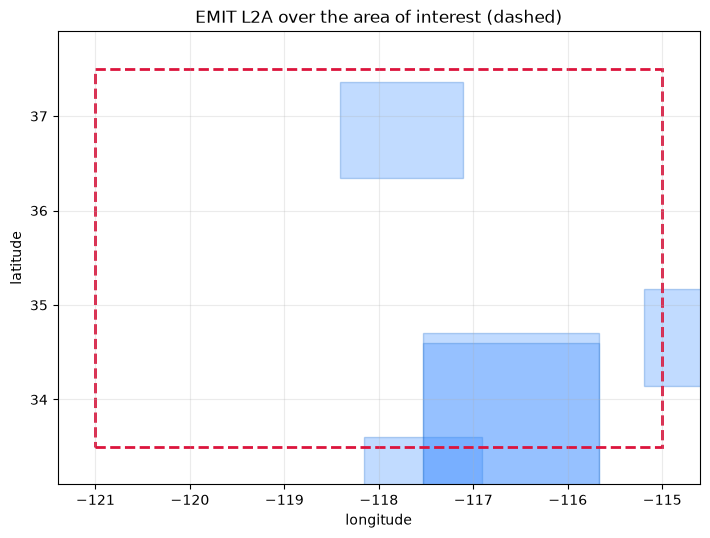

In [42]:
def footprints(results, title="", ax=None):
    '''Draw a result set's footprints and the area of interest, statically.

    Boxes with area are rectangles; a box with none - a NEON site - is a dot,
    for the same reason the interactive map uses a circle marker.
    '''
    if ax is None:
        _, ax = plt.subplots(figsize=(7.2, 5.4))
    for g in results:
        if g.bbox is None:
            continue
        w, s, e, n = g.bbox
        if e > w and n > s:
            ax.add_patch(plt.Rectangle((w, s), e - w, n - s, alpha=0.30, lw=1.0,
                                       edgecolor="#1f6fd0", facecolor="#3388ff"))
        else:
            ax.plot(w, s, "o", ms=9, mfc="#3388ff", mec="#1f6fd0")
    w, s, e, n = AOI
    ax.add_patch(plt.Rectangle((w, s), e - w, n - s, fill=False,
                               edgecolor="crimson", lw=2.0, ls="--"))
    ax.set_xlim(w - 0.4, e + 0.4); ax.set_ylim(s - 0.4, n + 0.4)
    ax.set_aspect("equal"); ax.grid(alpha=0.25)
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.set_title(title or f"{len(results)} footprints")
    return ax


_ = footprints(hits, "EMIT L2A over the area of interest (dashed)")
plt.tight_layout(); plt.show()

The footprints dwarf the dashed box, and that is normal: a search returns granules that
*intersect* your area, and an EMIT swath is roughly 75 km across. You will be downloading
a great deal of ground you did not ask for - which is the argument for reading `.table()`
before calling `download`.

## Step 5 - `hp.download()`

### `hp.download(results, out_dir="data", workers=8, *, token=None, user=None, password=None, pattern=None, verbose=True)`

| Parameter | Default | What it does |
|---|---|---|
| `results` | - | a `Results`, a list of granules, or one granule. **A mixture of archives is fine**: granules are grouped by where they came from and each group goes to its own backend |
| `out_dir` | `"data"` | created if missing. Everything lands **flat**, which is what the readers expect - they find a granule's siblings by name, in the same directory |
| `workers` | `8` | parallel connections |
| `token` | `None` | NEON API token, else `NEON_TOKEN` |
| `user`, `password` | `None` | DLR EOC account, else the environment, else `~/.netrc` |
| `pattern` | `None` | NEON only: which files inside a delivery to take. A delivery passed straight to `download` is expanded to its files first, so without a pattern this fetches a whole site-month |
| `verbose` | `True` | print the total before fetching anything, then each file |

Returns the downloaded paths. Files already present at the right size are skipped, and a
part-written file is named `.part` until it is complete, so an interrupted run never
leaves something that looks finished.

A credential meant for another archive is named rather than ignored: passing `token=` with
an EMIT result raises `TypeError`, because silently dropping it would leave you wondering
why the token had no effect.

# Part 2 - the tour: thirteen collections, one area

From here every collection gets the same three steps, so the code is one helper used
thirteen times and the prose is about what makes each collection different.

| | What it does |
|---|---|
| `look(sensor, level)` | searches with that collection's window from `TARGETS`, prints the listing, draws the static footprints, and returns the `Results` |
| `hp.search_map(results=...)` | the interactive map for that result set |
| `grab(sensor, level, hits)` | picks one scene by `PICK` and downloads it **if** `DOWNLOAD[(sensor, level)]` is on; otherwise prints exactly what it would fetch and why it stopped |

`grab` never downloads without saying the size first, and never proceeds without the
credential for that archive.

In [43]:
FOUND = {}          # (sensor, level) -> Results
GOT   = {}          # (sensor, level) -> [Path]


def look(sensor, level, count=None, **extra):
    '''Search one collection with its own window, list it, and map it statically.'''
    window, cloud = TARGETS[(sensor, level)]
    kw = dict(bbox=AOI, date=window, count=count or COUNT, **extra)
    if cloud is not None:
        kw["cloud"] = cloud
    hits = hp.search(sensor, level, **kw)
    FOUND[(sensor, level)] = hits
    print()
    print(hits.table())
    if len(hits):
        footprints(hits, f"{sensor} {level}  -  {len(hits)} footprints, {window[0]} to {window[1]}")
        plt.tight_layout(); plt.show()
    return hits


def choose(hits, how=None, take=None):
    '''Granules out of a result set, in a stated order rather than by luck.

    Returns a list, so TAKE=1 and TAKE="all" go down the same path. Both rules
    fall back to the archive's own order where the field they sort on is not
    published - see the note in step 0.
    '''
    how = how or PICK
    take = TAKE if take is None else take
    if not len(hits):
        return []
    if how == "smallest" and hits.unsized == 0:
        order = sorted(hits, key=lambda g: g.size_mb)
    elif how == "clearest" and any(g.cloud is not None for g in hits):
        order = sorted(hits, key=lambda g: (g.cloud is None, g.cloud or 0.0))
    else:
        order = list(hits)
    return order if take == "all" else order[:int(take)]


def grab(sensor, level, hits=None, how=None, take=None, **kw):
    '''Download the chosen scenes, if this collection's switch is on.'''
    hits = FOUND[(sensor, level)] if hits is None else hits
    picked = choose(hits, how, take)
    if not picked:
        print("nothing was found, so nothing to download")
        return []

    known = [g.size_mb for g in picked if g.size_mb is not None]
    total = sum(known) / 1024.0
    total_txt = (f"{total:,.1f} GB" if len(known) == len(picked)
                 else f"{total:,.1f} GB + {len(picked) - len(known)} unsized")
    print(f"chosen ({how or PICK}, take={TAKE if take is None else take}): "
          f"{len(picked)} of {len(hits)}, {total_txt}")
    for g in picked[:5]:
        size = f"{g.size_mb:>8,.0f} MB" if g.size_mb is not None else "  unsized"
        cloud = f"{g.cloud:>3.0f}% cloud" if g.cloud is not None else "         -"
        print(f"           {size}  {cloud}  {g.name[:52]}")
    if len(picked) > 5:
        print(f"           ... and {len(picked) - 5} more")

    backend = hp.archive.resolve(sensor, level)[2].backend
    if not DOWNLOAD[(sensor, level)]:
        print(f"         DOWNLOAD[{(sensor, level)}] is False - nothing fetched")
        return []
    # per mission for DLR, because the two take different accounts
    if not hp.archive.can_download(sensor, level):
        who, need = hp.archive.BACKENDS[backend]
        print(f"         no credentials for {sensor} at {who}; it needs {need}")
        print( "         set SIGN_IN = True in step 0 and rerun that cell to enter them")
        return []

    if backend == "neon" and not picked[0].links:
        # a NEON result is a whole site-month. TAKE=1 has to mean one
        # flightline here, or "one scene" would be several hundred gigabytes.
        lines = hp.files(picked[:1], verbose=False)
        if not len(lines):
            print("         the delivery listed no flightlines")
            return []
        picked = list(lines) if TAKE == "all" else list(lines)[:int(TAKE)]
        total = sum(g.size_mb or 0 for g in picked) / 1024.0
        print(f"         -> {len(picked)} flightline(s) of {len(lines)} in that "
              f"delivery, {total:,.1f} GB")
        if total > MAX_GB:
            print(f"         {total:,.1f} GB is over MAX_GB={MAX_GB} - nothing fetched")
            return []
    if total > MAX_GB:
        print(f"         {total:,.1f} GB is over MAX_GB={MAX_GB} - nothing fetched. "
              f"Raise MAX_GB, or lower TAKE")
        return []
    if len(known) < len(picked):
        # NEON and DLR publish no sizes, so MAX_GB has nothing to weigh. Say so
        # rather than let a ceiling that cannot apply look like protection.
        print(f"         note: {len(picked) - len(known)} of these publish no size, "
              f"so MAX_GB={MAX_GB} cannot bound this download")
        if backend == "neon":
            print( "               a NEON delivery is a whole site-month, often "
                   "hundreds of GB; narrow it with hp.files(..., pattern=...) first")

    t0 = time.time()
    paths = hp.download(picked, OUT, workers=4, **kw)
    GOT[(sensor, level)] = paths
    print(f"         {time.time() - t0:.0f} s")
    return paths

## NASA CMR

### EMIT L1B - at-sensor radiance

EMIT looks down from the International Space Station at 60 m, and is the one satellite in
this notebook whose radiance you are likely to correct yourself: `hyperproc.atmos` drives
ISOFIT over exactly this product.

A granule comes with **two siblings**, and both matter: the `OBS` file carries the sun and
view angles that every correction needs, and the `GLT` file is the geographic look-up
table that puts the retrieval back on a map. `hp.download` fetches all three because
`hp.open` looks for them by name in the same directory.

Note the ISS orbit: EMIT footprints over one area arrive at wildly different times of day
and are not on a repeat cycle, so "the same place next week" is not something you can plan.

searching EMITL1BRAD (EMIT L1B):
    bounding_box = (-121.0, 33.5, -115.0, 37.5)
    temporal = ('2023-01-01', '2025-12-31')
    cloud_cover = (0, 40)
  8 granules, 18.1 GB

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
EMIT_L1B_RAD_002_20230126T220221                     2023-01-26 22:02    1,873M     0%
EMIT_L1B_RAD_001_20230126T220233_2302615_003         2023-01-26 22:02    3,650M    25%
EMIT_L1B_RAD_002_20230126T220233                     2023-01-26 22:02    3,651M     1%
EMIT_L1B_RAD_002_20230129T211355                     2023-01-29 21:13    1,873M    22%
EMIT_L1B_RAD_002_20230130T202525                     2023-01-30 20:25    1,873M    34%
EMIT_L1B_RAD_001_20230202T193559_2303313_001         2023-02-02 19:35    1,872M    30%
EMIT_L1B_RAD_002_20230202T193559                     2023-02-02 19:35    1,873M    17%
EMIT_L1B_RAD_001_20230202T193611_2303

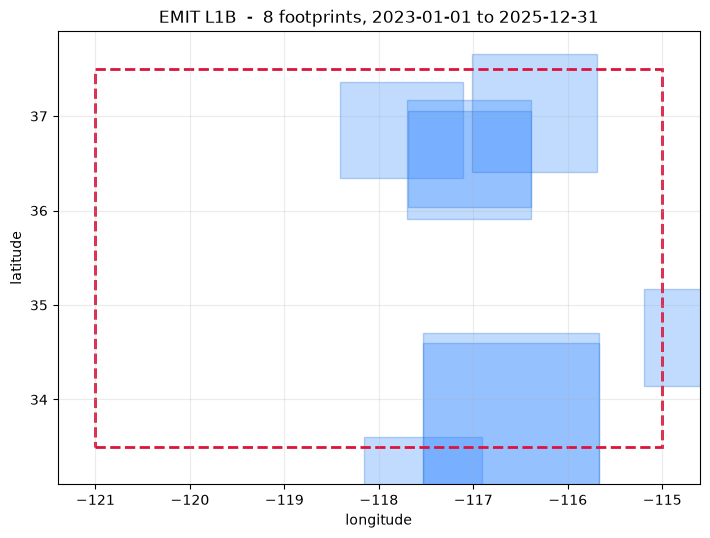

In [45]:
hits = look('EMIT', 'L1B')

In [46]:
hp.search_map(results=FOUND[('EMIT', 'L1B')], height="700px")

In [47]:
grab('EMIT', 'L1B')

chosen (smallest, take=1): 1 of 8, 1.8 GB
              1,872 MB   34% cloud  EMIT_L1B_RAD_001_20230202T193611_2303313_002
downloading 1 granule (1.8 GB) -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

  2 files in /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
         1 s


[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/EMIT_L1B_RAD_001_20230202T193611_2303313_002.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/EMIT_L1B_OBS_001_20230202T193611_2303313_002.nc')]

### EMIT L2A - surface reflectance

JPL's own atmospheric correction of the granule above, with `MASK` and `RFLUNCERT`
siblings instead of `OBS` and `GLT`. Start here if you want reflectance and do not need to
control the retrieval; start at L1B if you do.

`version=` is worth remembering for this collection in particular. EMIT carries **two live
versions** - 249,428 granules at v001 against 23,267 at v002 for the radiance - so
hyperproc leaves the version open and you see both. The `_001_` and `_002_` in the granule
names below are that difference.

searching EMITL2ARFL (EMIT L2A):
    bounding_box = (-121.0, 33.5, -115.0, 37.5)
    temporal = ('2023-01-01', '2025-12-31')
    cloud_cover = (0, 40)
  8 granules, 34.5 GB

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
EMIT_L2A_RFL_002_20230126T220221                     2023-01-26 22:02    3,556M     0%
EMIT_L2A_RFL_001_20230126T220233_2302615_003         2023-01-26 22:02    6,980M    25%
EMIT_L2A_RFL_002_20230126T220233                     2023-01-26 22:02    6,936M     1%
EMIT_L2A_RFL_002_20230129T211355                     2023-01-29 21:13    3,557M    22%
EMIT_L2A_RFL_002_20230130T202525                     2023-01-30 20:25    3,557M    34%
EMIT_L2A_RFL_001_20230202T193559_2303313_001         2023-02-02 19:35    3,580M    30%
EMIT_L2A_RFL_002_20230202T193559                     2023-02-02 19:35    3,557M    17%
EMIT_L2A_RFL_001_20230202T193611_2303

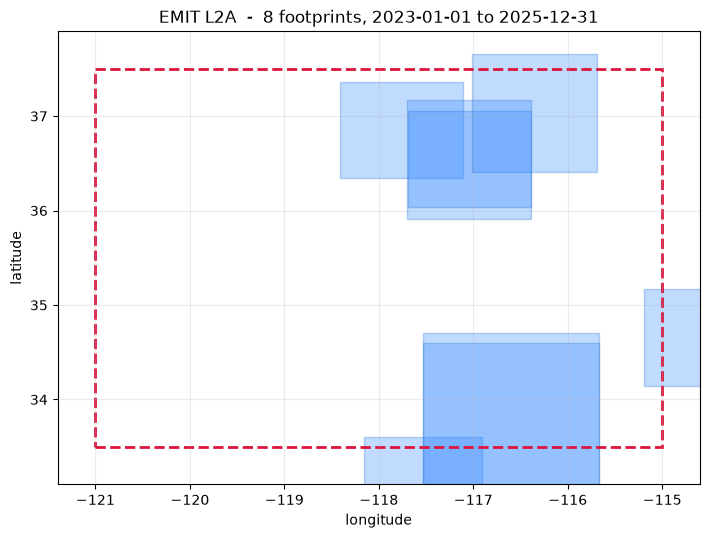

In [48]:
hits = look('EMIT', 'L2A')

In [49]:
hp.search_map(results=FOUND[('EMIT', 'L2A')], height="700px")

QUEUEING TASKS | :   0%|          | 0/8 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/8 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/8 [00:00<?, ?it/s]

In [50]:
grab('EMIT', 'L2A')

chosen (smallest, take=1): 1 of 8, 3.5 GB
              3,556 MB    0% cloud  EMIT_L2A_RFL_002_20230126T220221
downloading 1 granule (3.5 GB) -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

  2 files in /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
         1 s


[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/EMIT_L2A_RFL_002_20230126T220221.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/EMIT_L2A_RFLUNCERT_002_20230126T220221.nc')]

### PACE L1B - OCI science data

PACE's Ocean Colour Instrument covers the whole globe every one to two days at about
1.2 km, so unlike EMIT there is always something over your area - the window here is one
month rather than three years, and it still fills the result set.

The trade is resolution for coverage: one PACE granule is a swath thousands of kilometres
long, which is why a single scene covers the entire area of interest below rather than a
slice of it.

**This row of `TARGETS` has no cloud limit, and that is the interesting part.** PACE
publishes a cloud fraction at L2 and **none at L1B** - so a `cloud=` filter here could only
ever match nothing. Whether a cloud fraction exists is a property of the *collection*, not
of the sensor, which is why hyperproc records it per collection and refuses the filter
rather than handing back an empty result:

searching PACE_OCI_L1B_SCI (PACE L1B):
    bounding_box = (-121.0, 33.5, -115.0, 37.5)
    temporal = ('2024-03-01', '2024-03-31')
  8 granules, 14.2 GB

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
PACE_OCI_L1B_SCI_PACE_OCI.20240305T194403.L1B.V3.nc_ 2024-03-05 19:44    1,790M      -
PACE_OCI.20240305T194403.L1B.V3.nc                   2024-03-05 19:44    1,792M      -
PACE_OCI_L1B_SCI_PACE_OCI.20240305T194903.L1B.V3.nc_ 2024-03-05 19:49    1,790M      -
PACE_OCI.20240305T194903.L1B.V3.nc                   2024-03-05 19:49    1,799M      -
PACE_OCI_L1B_SCI_PACE_OCI.20240305T212224.L1B.V3.nc_ 2024-03-05 21:22    1,846M      -
PACE_OCI.20240305T212224.L1B.V3.nc                   2024-03-05 21:22    1,841M      -
PACE_OCI_L1B_SCI_PACE_OCI.20240306T201910.L1B.V3.nc_ 2024-03-06 20:19    1,818M      -
PACE_OCI.20240306T201910.L1B.V3.nc                   2024

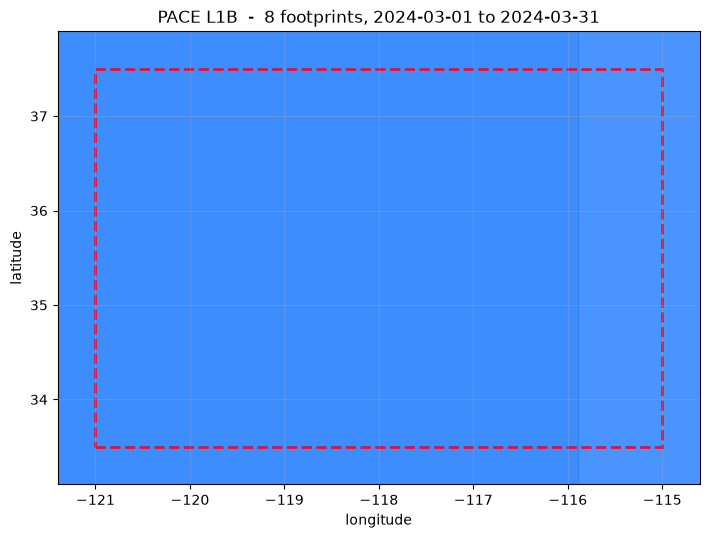

In [51]:
hits = look('PACE', 'L1B')

In [52]:
hp.search_map(results=FOUND[('PACE', 'L1B')], height="600px")

In [47]:
for pair in [("PACE", "L2"), ("PACE", "L1B")]:
    reports = hp.archive.COLLECTIONS[pair].cloud
    print(f"{pair[0]} {pair[1]:4s} reports a cloud fraction: {reports}")
    try:
        hp.search(*pair, bbox=AOI, date=TARGETS[pair][0], cloud=(0, 60),
                  count=1, verbose=False)
        print("          cloud=(0, 60) accepted")
    except ValueError as exc:
        print(f"          {exc}")
    print()

PACE L2   reports a cloud fraction: True
          cloud=(0, 60) accepted

PACE L1B  reports a cloud fraction: False
          PACE L1B does not report cloud cover (PACE_OCI_L1B_SCI carries no CloudCover field), so cloud=(0, 60) would exclude every granule rather than filtering them. Drop it.



In [48]:
grab('PACE', 'L1B')

chosen (smallest, take=1): 1 of 8, 1.7 GB
              1,790 MB           -  PACE_OCI_L1B_SCI_PACE_OCI.20240305T194403.L1B.V3.nc_
downloading 1 granule (1.7 GB) -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

  1 file in /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
         1 s


[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/PACE_OCI.20240305T194403.L1B.V3.nc')]

### PACE L2 - regional surface reflectance

The smallest granules of the thirteen, around 0.7 GB against EMIT's 3.5-6 GB, which is why
this is the one collection the notebook actually downloads by default. It is also a
one-file granule: no siblings to collect.

searching PACE_OCI_L2_SFREFL (PACE L2):
    bounding_box = (-121.0, 33.5, -115.0, 37.5)
    temporal = ('2024-03-01', '2024-03-31')
    cloud_cover = (0, 60)
  8 granules, 5.5 GB

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
PACE_OCI_L2_SFREFL_PACE_OCI.20240305T194403.L2.SFREF 2024-03-05 19:44      725M    26%
PACE_OCI_L2_SFREFL_PACE_OCI.20240308T195103.L2.SFREF 2024-03-08 19:51      709M    45%
PACE_OCI_L2_SFREFL_PACE_OCI.20240308T195603.L2.SFREF 2024-03-08 19:56      690M    58%
PACE_OCI_L2_SFREFL_PACE_OCI.20240310T192255.L2.SFREF 2024-03-10 19:22      711M    48%
PACE_OCI_L2_SFREFL_PACE_OCI.20240310T192755.L2.SFREF 2024-03-10 19:27      689M    55%
PACE_OCI_L2_SFREFL_PACE_OCI.20240311T195804.L2.SFREF 2024-03-11 19:58      709M    50%
PACE_OCI_L2_SFREFL_PACE_OCI.20240315T204009.L2.SFREF 2024-03-15 20:40      732M    52%
PACE_OCI_L2_SFREFL_PACE_OCI.202

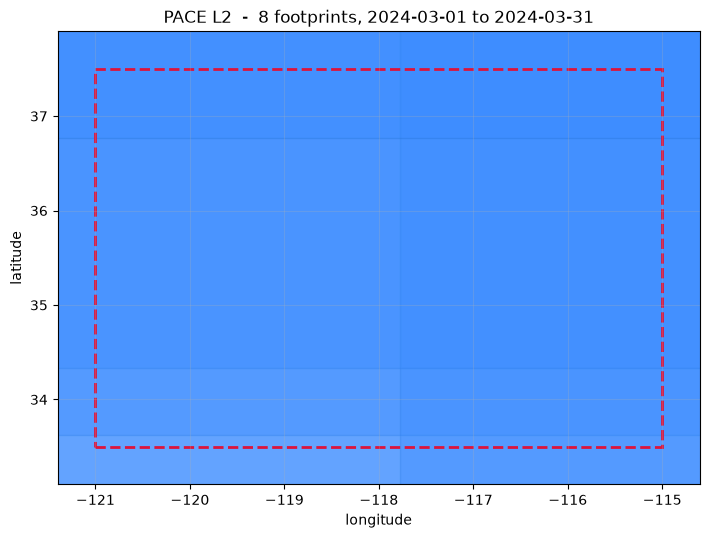

In [49]:
hits = look('PACE', 'L2')

In [90]:
hp.search_map(results=FOUND[('PACE', 'L2')], height="600px")

Map(center=[37.61236, -112.09861500000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

In [51]:
grab('PACE', 'L2')

chosen (smallest, take=1): 1 of 8, 0.7 GB
                689 MB   55% cloud  PACE_OCI_L2_SFREFL_PACE_OCI.20240310T192755.L2.SFREF
downloading 1 granule (0.7 GB) -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

  1 file in /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
         1 s


[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/PACE_OCI.20240310T192755.L2.SFREFL.V3_1.nc')]

### AVIRIS-3 L1B - airborne radiance

The first airborne collection, and the first real change of character. AVIRIS-3 flies on
an aircraft in **campaigns**, so coverage is a set of flight lines on a handful of days,
not a repeating orbit. An empty month means nobody flew, not that the search failed.

Look at the footprints: long, thin, and tilted. Those are flight lines, and the bounding
box you see is the *bounds* of a rotated strip - which is why hyperproc keeps the archive's
polygon in `Granule.raw` and gives you the box only as a summary.

**The AVIRIS collections report no cloud cover**, so `TARGETS` has `None` for them. Asking
for `cloud=(0, 30)` here would exclude every granule and look like an empty archive; the
search says so rather than letting you draw that conclusion.

searching AV3_L1B_RDN_2356 (AVIRIS-3 L1B):
    bounding_box = (-121.0, 33.5, -115.0, 37.5)
    temporal = ('2023-01-01', '2025-12-31')
  8 granules, 18.4 GB

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
AV320230705t195254_000_L1B_RDN_1                     2023-07-05 19:53    2,092M      -
AV320230705t195254_001_L1B_RDN_1                     2023-07-05 19:53    2,092M      -
AV320230705t195254_002_L1B_RDN_1                     2023-07-05 19:53    2,924M      -
AV320230705t202435_000_L1B_RDN_1                     2023-07-05 20:24    2,099M      -
AV320230705t202435_001_L1B_RDN_1                     2023-07-05 20:25    2,098M      -
AV320230705t202435_002_L1B_RDN_1                     2023-07-05 20:25    3,357M      -
AV320230705t202830_000_L1B_RDN_1                     2023-07-05 20:28    2,098M      -
AV320230705t202830_001_L1B_RDN_1                     

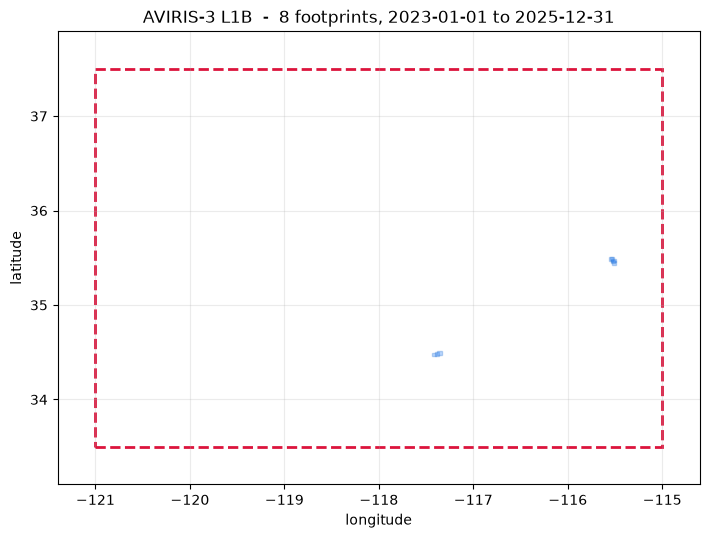

In [52]:
hits = look('AVIRIS-3', 'L1B')

In [91]:
hp.search_map(results=FOUND[('AVIRIS-3', 'L1B')], height="600px")

Map(center=[34.98296062994697, -116.46021655196739], controls=(ZoomControl(options=['position', 'zoom_in_text'…

In [54]:
grab('AVIRIS-3', 'L1B')

chosen (smallest, take=1): 1 of 8, 2.0 GB
              2,092 MB           -  AV320230705t195254_000_L1B_RDN_1
downloading 1 granule (2.0 GB) -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo


QUEUEING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/6 [00:00<?, ?it/s]

  6 files in /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
         42 s


[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV320230705t195254_000_L1B_RDN_cbeae6f8_RDN.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV320230705t195254_000_L1B_ORT_3b50f254_OBS.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV320230705t195254_000_L1B_RDN_cbeae6f8_BANDMASK.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV320230705t195254_000_L1B_RDN_cbeae6f8_RDN_QL.tif'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV320230705t195254_000_L1B_RDN_cbeae6f8.yaml'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV320230705t195254_000_L1B_ORT_3b50f254.yaml')]

### AVIRIS-3 L2A - orthocorrected reflectance

The collection that most needs its note read. AVIRIS-3 reflectance is published for only a
small share of flights - **511 granules against 21,501 of radiance** - so an empty result
here usually means that flight was never reflectance-processed, not that nothing was flown.

The fix is in this package: search `L1B`, and run `hyperproc.atmos.process` on the radiance
yourself. `hp.search` prints that advice on an empty result rather than leaving you to
guess.

searching AV3_L2A_RFL_2357 (AVIRIS-3 L2A):
    bounding_box = (-121.0, 33.5, -115.0, 37.5)
    temporal = ('2023-01-01', '2025-12-31')
  8 granules, 14.8 GB

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
AV320240905t175818_000_L2A_RFL_1                     2024-09-05 17:58    1,904M      -
AV320240905t175818_001_L2A_RFL_1                     2024-09-05 17:58    1,855M      -
AV320240905t175818_002_L2A_RFL_1                     2024-09-05 17:58    1,960M      -
AV320240905t175818_003_L2A_RFL_1                     2024-09-05 17:58    1,974M      -
AV320240905t175818_004_L2A_RFL_1                     2024-09-05 17:59    1,852M      -
AV320240905t175818_005_L2A_RFL_1                     2024-09-05 17:59    1,801M      -
AV320240905t175818_006_L2A_RFL_1                     2024-09-05 17:59    1,906M      -
AV320240905t175818_007_L2A_RFL_1                     

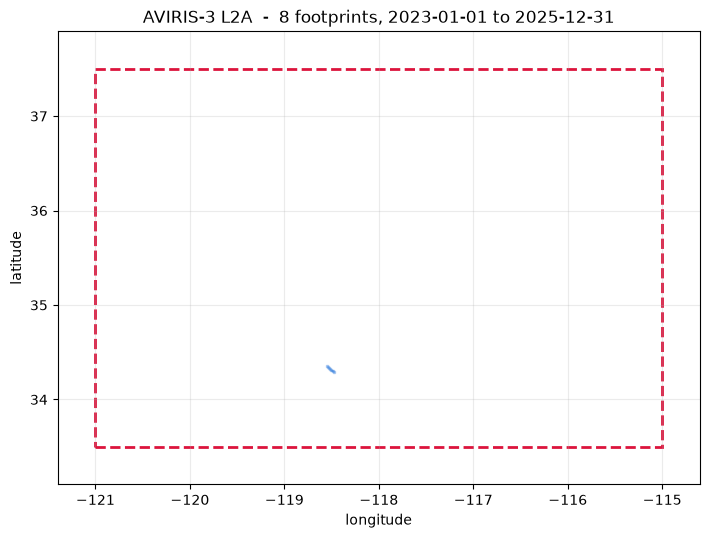

In [55]:
hits = look('AVIRIS-3', 'L2A')

In [92]:
hp.search_map(results=FOUND[('AVIRIS-3', 'L2A')], height="600px")

Map(center=[34.32038685237359, -118.51191959082611], controls=(ZoomControl(options=['position', 'zoom_in_text'…

In [57]:
grab('AVIRIS-3', 'L2A')

chosen (smallest, take=1): 1 of 8, 1.8 GB
              1,801 MB           -  AV320240905t175818_005_L2A_RFL_1
downloading 1 granule (1.8 GB) -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

  4 files in /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
         39 s


[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV320240905t175818_005_L2A_OE_f576f24d_RFL_ORT.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV320240905t175818_005_L2A_OE_f576f24d_UNC_ORT.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV320240905t175818_005_L2A_OE_f576f24d_RFL_ORT_QL.tif'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV320240905t175818_005_L2A_OE_f576f24d.yaml')]

### AVIRIS-5 L1B - the newest airborne radiance

AVIRIS-5 began science flights in 2025, which is why its window is one year. The archive is
small for now - 5,811 radiance granules - and the flight lines are longer than AVIRIS-3's,
so a single granule can be tens of gigabytes.

This is the collection where reading `.table()` before `download` stops being advice and
starts being necessary.

searching AV5_L1B_RDN_2483 (AVIRIS-5 L1B):
    bounding_box = (-121.0, 33.5, -115.0, 37.5)
    temporal = ('2025-01-01', '2025-12-31')
  8 granules, 43.8 GB

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
AV520250429t185930_000_L1B_RDN_1                     2025-04-29 18:59    4,877M      -
AV520250429t185930_001_L1B_RDN_1                     2025-04-29 19:01    4,875M      -
AV520250429t185930_002_L1B_RDN_1                     2025-04-29 19:02    5,476M      -
AV520250429t190705_000_L1B_RDN_1                     2025-04-29 19:07    4,946M      -
AV520250429t190705_001_L1B_RDN_1                     2025-04-29 19:08    4,914M      -
AV520250429t190705_002_L1B_RDN_1                     2025-04-29 19:09    9,885M      -
AV520250429t191403_000_L1B_RDN_1                     2025-04-29 19:14    4,968M      -
AV520250429t191403_001_L1B_RDN_1                     

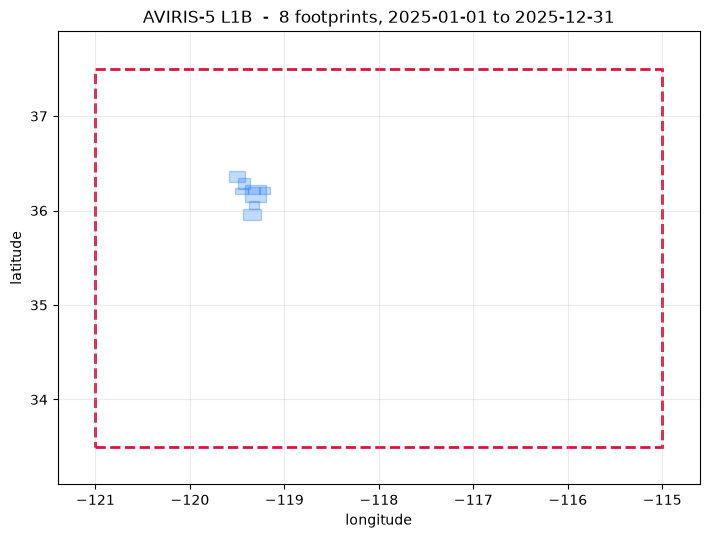

In [58]:
hits = look('AVIRIS-5', 'L1B')

In [93]:
hp.search_map(results=FOUND[('AVIRIS-5', 'L1B')], height="600px")

Map(center=[36.159590669955236, -119.36593539747135], controls=(ZoomControl(options=['position', 'zoom_in_text…

In [60]:
grab('AVIRIS-5', 'L1B')

chosen (smallest, take=1): 1 of 8, 4.8 GB
              4,875 MB           -  AV520250429t185930_001_L1B_RDN_1
downloading 1 granule (4.8 GB) -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo


QUEUEING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/6 [00:00<?, ?it/s]

  6 files in /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
         113 s


[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV520250429t185930_001_L1B_RDN_410aa9e4_RDN.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV520250429t185930_001_L1B_ORT_473b0540.yaml'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV520250429t185930_001_L1B_ORT_473b0540_OBS.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV520250429t185930_001_L1B_RDN_410aa9e4.yaml'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV520250429t185930_001_L1B_RDN_410aa9e4_BANDMASK.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV520250429t185930_001_L1B_RDN_410aa9e4_RDN_QL.tif')]

### AVIRIS-5 L2A - orthocorrected reflectance

Unlike AVIRIS-3, AVIRIS-5's reflectance is published for nearly every flight - 5,776
granules against 5,811 of radiance. Two instruments from the same laboratory, two
completely different odds of finding an L2A for a given flight, and the only way to know
is that the numbers are in the table.

searching AV5_L2A_RFL_2484 (AVIRIS-5 L2A):
    bounding_box = (-121.0, 33.5, -115.0, 37.5)
    temporal = ('2025-01-01', '2025-12-31')
  8 granules, 46.4 GB

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
AV520250429t203229_000_L2A_RFL_1                     2025-04-29 20:32    7,069M      -
AV520250505t171136_000_L2A_RFL_1                     2025-05-05 17:11    3,237M      -
AV520250505t175429_000_L2A_RFL_1                     2025-05-05 17:54    7,074M      -
AV520250505t175429_001_L2A_RFL_1                     2025-05-05 17:56    4,770M      -
AV520250505t175429_002_L2A_RFL_1                     2025-05-05 17:58    6,095M      -
AV520250505t180330_000_L2A_RFL_1                     2025-05-05 18:03    7,482M      -
AV520250505t180330_001_L2A_RFL_1                     2025-05-05 18:05    4,901M      -
AV520250505t180330_002_L2A_RFL_1                     

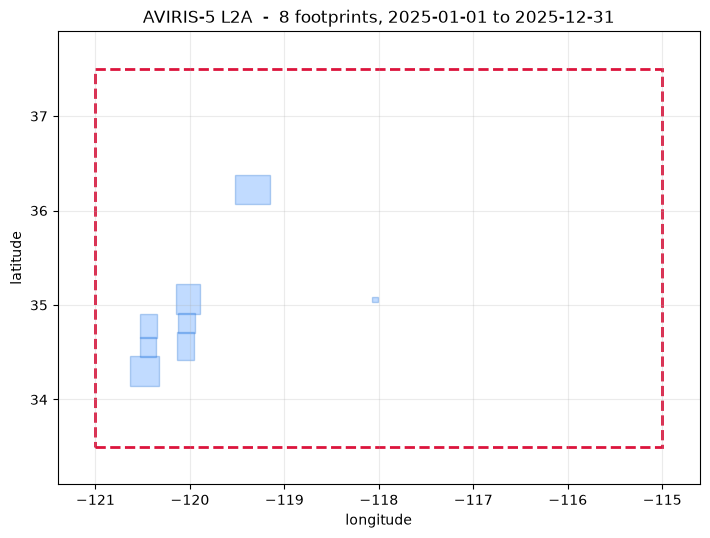

In [61]:
hits = look('AVIRIS-5', 'L2A')

In [ ]:
hp.search_map(results=FOUND[('AVIRIS-5', 'L2A')], height="600px")

Map(center=[35.25556697110861, -119.31852028249222], controls=(ZoomControl(options=['position', 'zoom_in_text'…

In [63]:
grab('AVIRIS-5', 'L2A')

chosen (smallest, take=1): 1 of 8, 3.2 GB
              3,237 MB           -  AV520250505t171136_000_L2A_RFL_1
downloading 1 granule (3.2 GB) -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

  4 files in /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
         58 s


[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV520250505t171136_000_L2A_OE_ed596193_RFL_ORT.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV520250505t171136_000_L2A_OE_ed596193_UNC_ORT.nc'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV520250505t171136_000_L2A_OE_ed596193.yaml'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/AV520250505t171136_000_L2A_OE_ed596193_RFL_ORT_QL.tif')]

## NEON

### NEON L1 - AOP flightline reflectance

The collection that does not fit the shape of the others, in three ways.

**A result is a month, not a granule.** NEON publishes *deliveries*: one per site per
month, holding every flightline flown in that window - often a hundred files and several
hundred gigabytes. So finding NEON data is two steps, and only the first is free:

```python
hits  = hp.search("NEON", "L1", bbox=AOI)     # deliveries, anonymous
lines = hp.files(hits[0])                      # the flightlines inside, needs a token
hp.download(lines[:2], OUT)
```

**A footprint is a point.** NEON publishes a site's coordinates through the API but not its
flight box, so `bbox` here is `(lon, lat, lon, lat)`, drawn as a dot below and as a circle
on the interactive map. `site_radius_km` (default 15, an AOP flight box being roughly 10 km
across) is how far outside your box a site may sit and still match - a stated tolerance,
not an invented polygon.

**There is no size**, because a delivery's size is not known until its files are listed,
and listing needs a token.

Three NEON sites fall in this area of interest: **SJER** (San Joaquin Experimental Range),
**SOAP** (Soaproot Saddle) and **TEAK** (Lower Teakettle), a low-elevation to
high-elevation transect in the Sierra Nevada.

searching DP1.30006.001 (NEON L1):
    bbox = (-121.0, 33.5, -115.0, 37.5)
    date = ('2021-01', '2024-12')
  8 granules, size not published
  each is a whole site-month; hyperproc.archive.files() lists the flightlines inside one (needs a NEON API token)

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
DP1.30006.001/TEAK/2024-06                           2024-06-01 00:00        -      -
DP1.30006.001/SOAP/2024-06                           2024-06-01 00:00        -      -
DP1.30006.001/SJER/2024-04                           2024-04-01 00:00        -      -
DP1.30006.001/TEAK/2023-07                           2023-07-01 00:00        -      -
DP1.30006.001/SOAP/2023-07                           2023-07-01 00:00        -      -
DP1.30006.001/SOAP/2023-06                           2023-06-01 00:00        -      -
DP1.30006.001/SJER/2023-04                     

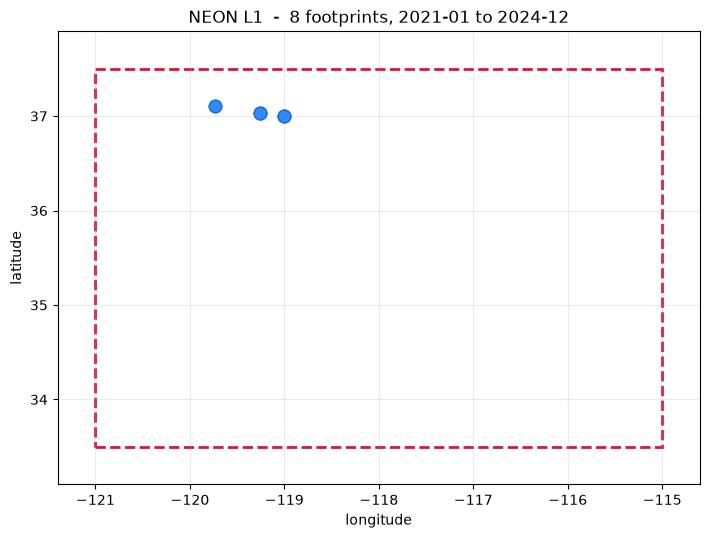

In [64]:
hits = look('NEON', 'L1')

In [ ]:
hp.search_map(results=FOUND[('NEON', 'L1')], height="600px")

Map(center=[37.057305, -119.36915], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

Before downloading, a NEON delivery has to be opened up.

### `hp.files(results, *, token=None, pattern=None, verbose=True)`

| Parameter | Default | What it does |
|---|---|---|
| `results` | - | what `search` returned, a list of deliveries, or one on its own |
| `token` | `None` | the NEON API token. Falls back to `NEON_TOKEN` |
| `pattern` | `None` | a shell glob over file names. The default keeps only what `hp.open` reads - `*_reflectance.h5` for DP1.30006.001 - because a delivery also carries flight logs, KML footprints and readmes. `"*"` keeps everything |
| `verbose` | `True` | print what was found |

Returns a `Results` with one granule per file, each with a real size and a link. For the
other two archives a granule already *is* its files, so `hp.files` returns what it was
given unchanged - one script then works against every archive.

**The links NEON returns are signed and expire within the hour**, so list and download in
one sitting rather than pickling the result and coming back tomorrow.

`hp.files` does **not** check for a token before it asks. The endpoint is NEON's to open or
close, and refusing locally would lock out anyone NEON does still answer. The request goes
out, and the refusal - if there is one - produces the message below.

In [66]:
try:
    lines = hp.files(FOUND[("NEON", "L1")][:1])
    print(lines.table())
except PermissionError as exc:
    print("PermissionError:")
    print(" ", exc)

  40 granules, 388.8 GB
granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
NEON_D17_TEAK_DP1_L004-1_20240612_directional_reflec 2024-06-01 00:00    9,889M      -
NEON_D17_TEAK_DP1_L019-1_20240612_directional_reflec 2024-06-01 00:00    9,611M      -
NEON_D17_TEAK_DP1_L018-1_20240612_directional_reflec 2024-06-01 00:00    9,629M      -
NEON_D17_TEAK_DP1_L017-1_20240612_directional_reflec 2024-06-01 00:00   10,282M      -
NEON_D17_TEAK_DP1_L016-1_20240612_directional_reflec 2024-06-01 00:00   10,926M      -
NEON_D17_TEAK_DP1_L009-1_20240612_directional_reflec 2024-06-01 00:00   10,458M      -
NEON_D17_TEAK_DP1_L007-1_20240612_directional_reflec 2024-06-01 00:00   10,923M      -
NEON_D17_TEAK_DP1_L005-1_20240612_directional_reflec 2024-06-01 00:00    9,769M      -
NEON_D17_TEAK_DP1_L006-1_20240612_directional_reflec 2024-06-01 00:00    9,973M      -
NEON_D17_TEAK

That message is the deliverable. NEON's data endpoint returns a bare
`403 {"error": {"detail": "Access Denied"}}` with no explanation, for every product, and
gives the same 403 for a wrong token as for no token.

Plenty of older NEON scripts look like this, and they were right until recently:

```python
product_request = requests.get(
    'https://data.neonscience.org/api/v0/data/%s/%s/%s' % (dpid, site, month)).json()
files = product_request['data']['files']          # TypeError today
```

`data` now comes back `null`, so that line raises `TypeError: 'NoneType' object is not
subscriptable` - which says nothing at all about tokens. The requirement is stated in
NEON's own client (`NEONScience/NEON-utilities-python`, `helper_mods/api_helpers.py`):

> As of June 2026, NEON requires an API token for data download.

It is a policy, not a network problem: from this machine `/products`, `/sites`,
`/locations` and `/releases` all return 200 and every `/data/...` path returns 403. A token
is free from your account page and takes a minute; `/sites` and `/products` staying open is
exactly why the search and the map above needed nothing.

In [67]:
grab('NEON', 'L1')

chosen (smallest, take=1): 1 of 8, 0.0 GB + 1 unsized
             unsized           -  DP1.30006.001/TEAK/2024-06
         -> 1 flightline(s) of 40 in that delivery, 9.7 GB
         note: 1 of these publish no size, so MAX_GB=10 cannot bound this download
               a NEON delivery is a whole site-month, often hundreds of GB; narrow it with hp.files(..., pattern=...) first
downloading 1 file (9.7 GB) -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
  NEON_D17_TEAK_DP1_L004-1_20240612_directional_reflectance.h5  9,889 MB
  1 file in /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
         199 s


[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/NEON_D17_TEAK_DP1_L004-1_20240612_directional_reflectance.h5')]

## DLR EOC Geoservice

### EnMAP L1B - at-sensor radiance, detectors unmerged

EnMAP and DESIS are not in NASA's CMR at all. DLR's Earth Observation Center runs its own
STAC catalogue, fully open to search - 238,494 EnMAP L2A scenes - with only the file server
gated.

**L1B ships the two detectors as separate files.** The VNIR and SWIR focal planes are not
co-registered until L1C, so `hp.open` on an L1B refuses `cube="full"` and makes you pick
`"vnir"` or `"swir"`; stacking them by pixel index would give spectra whose bands come from
different ground spots. That is why this collection lists two `SPECTRAL_IMAGE_*` files
where L1C and L2A list one.

### Signing in to DLR is not HTTP Basic

Worth knowing before the first download fails at you. The file server answers **403 to an
`Authorization` header, with no `WWW-Authenticate` challenge** - which is how you can tell
Basic auth is not the mechanism - and redirects everything else to DLR's CAS single
sign-on. So `hp.download` carries the login form through once per mission and keeps the
session cookie.

Two more things follow from that:

* **the first sign-in may stop at an Acceptable Usage Policy.** That is DLR asking *you*
  to agree to something, so hyperproc does not click it for you. Read it with
  `hp.archive.dlr.read_policy("DESIS")` - handy on a server with no browser - then either
  accept it once in a browser or pass `accept_policy=True`. The account remembers it;
  * **EnMAP and DESIS have separate policies**, as they have separate accounts.

Two things about the archive itself:

* **DLR publishes no file sizes.** `size_mb` is `None` here and for DESIS - not an
  estimate, and not zero;
* **a cloud filter needs a bounding box.** DLR ignores the STAC `query` extension, so
  `cloud=` goes out as a CQL2 filter, and a CQL2 filter with no box scans all 238,494 items
  and times out rather than answering. `hp.search` refuses that combination locally instead
  of letting you wait for it.

searching ENMAP_HSI_L1B (ENMAP L1B):
    bbox = (-121.0, 33.5, -115.0, 37.5)
    date = 2023-01-01T00:00:00Z/2024-12-31T23:59:59Z
    cloud = (0, 30)
  8 granules, size not published of 584 matching

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V0 2024-12-20 19:13        -    10%
ENMAP01-____L1B-DT0000107338_20241220T191326Z_002_V0 2024-12-20 19:13        -     0%
ENMAP01-____L1B-DT0000107338_20241220T191321Z_001_V0 2024-12-20 19:13        -     0%
ENMAP01-____L1B-DT0000103238_20241127T191649Z_022_V0 2024-11-27 19:16        -    28%
ENMAP01-____L1B-DT0000103238_20241127T191631Z_018_V0 2024-11-27 19:16        -    30%
ENMAP01-____L1B-DT0000103238_20241127T191627Z_017_V0 2024-11-27 19:16        -    17%
ENMAP01-____L1B-DT0000102006_20241119T190955Z_004_V0 2024-11-19 19:09        -     2%
ENMAP01-____L1B-DT

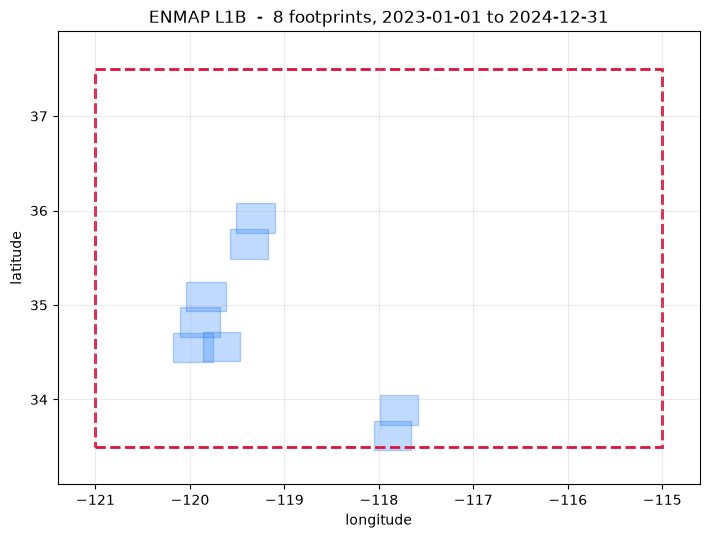

In [20]:
hits = look('ENMAP', 'L1B')

In [94]:
hp.search_map(results=FOUND[('ENMAP', 'L1B')], height="600px")

Map(center=[34.768574405500004, -118.881926114], controls=(ZoomControl(options=['position', 'zoom_in_text', 'z…

In [22]:
# accept_policy=True agrees to DLR's usage policy from here; read it
# first with hp.archive.dlr.read_policy('ENMAP')
grab('ENMAP', 'L1B')

chosen (smallest, take=1): 1 of 8, 0.0 GB + 1 unsized
             unsized   10% cloud  ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V0
         note: 1 of these publish no size, so MAX_GB=10 cannot bound this download
downloading 1 granule, 12 files -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
  signed in to DLR for ENMAP
  ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLASSES_COG.TIF  0 MB
  ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-METADATA.XML  4 MB
  ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUD_COG.TIF  0 MB
  ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUDSHADOW_COG.TIF  0 MB
  ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_HAZE_COG.TIF  0 MB
  ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CIRRUS_COG.TIF  0 M

[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-METADATA.XML'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-SPECTRAL_IMAGE_SWIR_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-SPECTRAL_IMAGE_VNIR_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLASSES_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUD_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_de

### EnMAP L1C - orthorectified radiance

The same radiance, resampled onto a map grid with the two detectors brought into register -
one `SPECTRAL_IMAGE` file, 224 bands. Slightly fewer scenes exist than at L1B or L2A
(206,404 against 238,501), because L1C is generated on demand rather than for everything.

This is the level `hyperproc.atmos` uses for EnMAP: orthorectified, one cube, still
radiance.

searching ENMAP_HSI_L1C (ENMAP L1C):
    bbox = (-121.0, 33.5, -115.0, 37.5)
    date = 2023-01-01T00:00:00Z/2024-12-31T23:59:59Z
    cloud = (0, 30)
  8 granules, size not published of 529 matching

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V0 2024-12-20 19:13        -    10%
ENMAP01-____L1C-DT0000107338_20241220T191326Z_002_V0 2024-12-20 19:13        -     0%
ENMAP01-____L1C-DT0000107338_20241220T191321Z_001_V0 2024-12-20 19:13        -     0%
ENMAP01-____L1C-DT0000099447_20241031T191648Z_003_V0 2024-10-31 19:16        -     0%
ENMAP01-____L1C-DT0000099447_20241031T191644Z_002_V0 2024-10-31 19:16        -     2%
ENMAP01-____L1C-DT0000099447_20241031T191640Z_001_V0 2024-10-31 19:16        -    20%
ENMAP01-____L1C-DT0000098893_20241023T191004Z_004_V0 2024-10-23 19:10        -     1%
ENMAP01-____L1C-DT

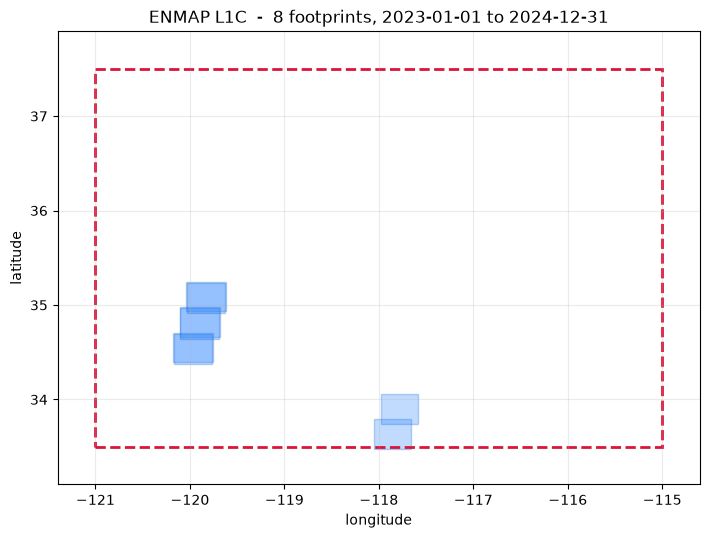

In [23]:
hits = look('ENMAP', 'L1C')

In [98]:
hp.search_map(results=FOUND[('ENMAP', 'L1C')], height="600px")

Map(center=[34.3608239, -118.88054025], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_ti…

In [25]:
# accept_policy=True agrees to DLR's usage policy from here; read it
# first with hp.archive.dlr.read_policy('ENMAP')
grab('ENMAP', 'L1C')

chosen (smallest, take=1): 1 of 8, 0.0 GB + 1 unsized
             unsized   10% cloud  ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V0
         note: 1 of these publish no size, so MAX_GB=10 cannot bound this download
downloading 1 granule, 10 files -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
  signed in to DLR for ENMAP
  ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUD_COG.TIF  0 MB
  ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLASSES_COG.TIF  0 MB
  ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUDSHADOW_COG.TIF  0 MB
  ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CIRRUS_COG.TIF  0 MB
  ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_HAZE_COG.TIF  0 MB
  ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_TESTFL

[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-METADATA.XML'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-SPECTRAL_IMAGE_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLASSES_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUD_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L1C-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUDSHADOW_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo

### EnMAP L2A - surface reflectance

DLR's own atmospheric correction, land or water. The largest of the three EnMAP
collections and the usual starting point.

**Look at the file names below.** DLR's catalogue links *cloud-optimised* copies, whose
names carry an extra `_COG` before the extension, while the order form delivers the plain
`.TIF`. hyperproc's EnMAP reader accepts both spellings and finds `_COG` siblings for a
`_COG` granule, so a scene fetched here opens with nothing renamed - which is the sort of
thing that is invisible when it works and an afternoon of confusion when it does not.

searching ENMAP_HSI_L2A (ENMAP L2A):
    bbox = (-121.0, 33.5, -115.0, 37.5)
    date = 2023-01-01T00:00:00Z/2024-12-31T23:59:59Z
    cloud = (0, 30)
  8 granules, size not published of 584 matching

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V0 2024-12-20 19:13        -    10%
ENMAP01-____L2A-DT0000107338_20241220T191326Z_002_V0 2024-12-20 19:13        -     0%
ENMAP01-____L2A-DT0000107338_20241220T191321Z_001_V0 2024-12-20 19:13        -     0%
ENMAP01-____L2A-DT0000103238_20241127T191649Z_022_V0 2024-11-27 19:16        -    28%
ENMAP01-____L2A-DT0000103238_20241127T191631Z_018_V0 2024-11-27 19:16        -    30%
ENMAP01-____L2A-DT0000103238_20241127T191627Z_017_V0 2024-11-27 19:16        -    17%
ENMAP01-____L2A-DT0000102006_20241119T190955Z_004_V0 2024-11-19 19:09        -     2%
ENMAP01-____L2A-DT

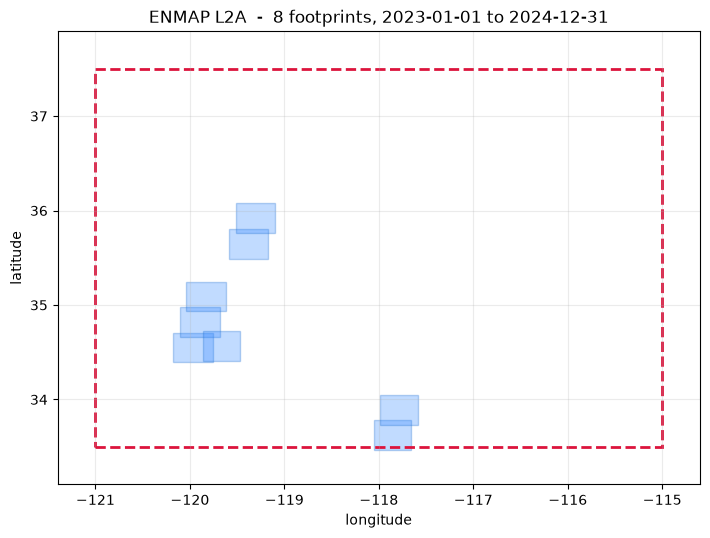

In [26]:
hits = look('ENMAP', 'L2A')

In [99]:
hp.search_map(results=FOUND[('ENMAP', 'L2A')], height="600px")

Map(center=[34.76989795, -118.88157405000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoo…

### `assets=` - which files of a scene you get

An EnMAP scene has thirteen published files and a DESIS scene six. `assets=` chooses which
of them a result links to, by **file name** rather than by the catalogue's asset keys, so
one rule covers both sensors.

| Value | What it links | When |
|---|---|---|
| `"reader"` | metadata, the spectral image, and the quality and pixel masks | the default: exactly what `hp.open` uses |
| `"image"` | metadata and the spectral image only | when you will not touch the masks and want the download small |
| `"all"` | everything, including browse images and thumbnails | when you want the delivery as the provider ships it |

In [28]:
for choice in ("image", "reader", "all"):
    one = hp.search("ENMAP", "L2A", bbox=AOI, date=TARGETS[("ENMAP", "L2A")][0],
                    count=1, assets=choice, verbose=False)
    print(f"assets={choice!r:9s} -> {len(one[0].links)} files")
    if choice == "reader":
        for url in one[0].links:
            print("     ", url.rsplit("-", 1)[-1])

assets='image'   -> 2 files
assets='reader'  -> 10 files
      METADATA.XML
      SPECTRAL_IMAGE_COG.TIF
      QL_QUALITY_CLASSES_COG.TIF
      QL_QUALITY_CLOUD_COG.TIF
      QL_QUALITY_CLOUDSHADOW_COG.TIF
      QL_QUALITY_HAZE_COG.TIF
      QL_QUALITY_CIRRUS_COG.TIF
      QL_QUALITY_SNOW_COG.TIF
      QL_QUALITY_TESTFLAGS_COG.TIF
      QL_PIXELMASK_COG.TIF
assets='all'     -> 13 files


In [29]:
# accept_policy=True agrees to DLR's usage policy from here; read it
# first with hp.archive.dlr.read_policy('ENMAP')
grab('ENMAP', 'L2A')

chosen (smallest, take=1): 1 of 8, 0.0 GB + 1 unsized
             unsized   10% cloud  ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V0
         note: 1 of these publish no size, so MAX_GB=10 cannot bound this download
downloading 1 granule, 10 files -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
  signed in to DLR for ENMAP
  ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUD_COG.TIF  0 MB
  ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLASSES_COG.TIF  0 MB
  ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUDSHADOW_COG.TIF  0 MB
  ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_HAZE_COG.TIF  0 MB
  ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CIRRUS_COG.TIF  0 MB
  ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-METADATA.XML  4 M

[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-METADATA.XML'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-SPECTRAL_IMAGE_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLASSES_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUD_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/ENMAP01-____L2A-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z-QL_QUALITY_CLOUDSHADOW_COG.TIF'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo

### DESIS L2A - surface reflectance from the ISS

The last of the thirteen, and the one with a closed archive.

**DESIS's public catalogue stops at the end of 2021**, which is why its window in `TARGETS`
is 2019-2021 while everything else is recent. Asking for 2023 returns an empty result, and
that is correct - a sensor that no longer delivers is a different thing from a query that
found nothing, and the only way to tell them apart is to know the mission.

Only **L2A** is public here. DESIS L1B and L1C are ordered commercially through Teledyne
Brown; `hp.open` reads them once you have them, and `resolve("DESIS", "L1B")` says exactly
that instead of a bare "no such level" - step 6 shows it.

Note also that the DESIS files are named plainly: no `_COG`, unlike EnMAP, from the same
archive.

searching DESIS_HSI_L2A (DESIS L2A):
    bbox = (-121.0, 33.5, -115.0, 37.5)
    date = 2019-01-01T00:00:00Z/2021-12-31T23:59:59Z
    cloud = (0, 30)
  8 granules, size not published of 281 matching

granule                                              when                  size  cloud
--------------------------------------------------------------------------------------------
DESIS-HSI-L2A-DT0667868308_019-20211218T214555-V0220 2021-12-18 21:48        -     0%
DESIS-HSI-L2A-DT0667868308_018-20211218T214555-V0220 2021-12-18 21:48        -     0%
DESIS-HSI-L2A-DT0667868308_017-20211218T214555-V0220 2021-12-18 21:48        -     0%
DESIS-HSI-L2A-DT0667868308_016-20211218T214555-V0220 2021-12-18 21:48        -     0%
DESIS-HSI-L2A-DT0662698352_007-20211204T195153-V0220 2021-12-04 19:53        -     0%
DESIS-HSI-L2A-DT0662698352_006-20211204T195153-V0220 2021-12-04 19:53        -     0%
DESIS-HSI-L2A-DT0662698352_005-20211204T195153-V0220 2021-12-04 19:53        -     0%
DESIS-HSI-L2A-DT06

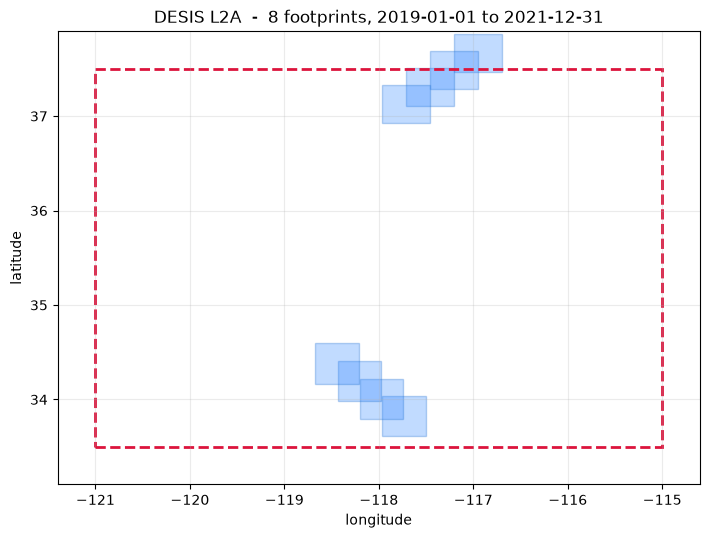

In [30]:
hits = look('DESIS', 'L2A')

In [96]:
hp.search_map(results=FOUND[('DESIS', 'L2A')], height="600px")

Map(center=[35.736185584787435, -117.68166247114462], controls=(ZoomControl(options=['position', 'zoom_in_text…

In [32]:
# accept_policy=True agrees to DLR's usage policy from here; read it
# first with hp.archive.dlr.read_policy('DESIS')
grab('DESIS', 'L2A')

chosen (smallest, take=1): 1 of 8, 0.0 GB + 1 unsized
             unsized    0% cloud  DESIS-HSI-L2A-DT0667868308_019-20211218T214555-V0220
         note: 1 of these publish no size, so MAX_GB=10 cannot bound this download
downloading 1 granule, 4 files -> /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
  signed in to DLR for DESIS
  4 files in /data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo
         2 s


[PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/DESIS-HSI-L2A-DT0667868308_019-20211218T214555-V0220-METADATA.xml'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/DESIS-HSI-L2A-DT0667868308_019-20211218T214555-V0220-SPECTRAL_IMAGE.tif'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/DESIS-HSI-L2A-DT0667868308_019-20211218T214555-V0220-QL_QUALITY.tif'),
 PosixPath('/data/fujiang/Hyperspectral_data_processing/tests/output/archive_demo/DESIS-HSI-L2A-DT0667868308_019-20211218T214555-V0220-QL_QUALITY-2.tif')]

## The tour, in one table

Thirteen collections, one area of interest, one function.

In [ ]:
print(f"{'sensor':10s} {'level':5s} {'backend':6s} {'hits':>5s} {'size':>12s}  "
      f"{'cloud':>6s}  window")
print("-" * 92)
for (sensor, level), hits in FOUND.items():
    backend = hp.archive.resolve(sensor, level)[2].backend
    size = f"{hits.size_gb:,.1f} GB" if hits.unsized == 0 and len(hits) else \
           ("unpublished" if len(hits) else "-")
    clouds = [g.cloud for g in hits if g.cloud is not None]
    cloud = f"{min(clouds):.0f}-{max(clouds):.0f}%" if clouds else "-"
    window = TARGETS[(sensor, level)][0]
    print(f"{sensor:10s} {level:5s} {backend:6s} {len(hits):5d} {size:>12s}  "
          f"{cloud:>6s}  {window[0]} .. {window[1]}")
print("-" * 92)
print(f"{sum(len(h) for h in FOUND.values())} granules found, "
      f"{sum(h.size_gb for h in FOUND.values()):,.0f} GB of the ones that publish a size")
print(f"{sum(len(p) for p in GOT.values())} file(s) actually downloaded")

# Part 3 - refusals, and what happens after a download

## Step 6 - every way this can refuse you

A search that quietly returns nothing is worse than one that explains itself, so the module
refuses in seven different ways and each names the reason.

| What you ask | What happens |
|---|---|
| a sensor no archive here carries | `ValueError` with the address of the archive that does |
| a sensor that is not a sensor | `ValueError` listing what *is* searchable |
| a sensor with two levels, and no level | `ValueError` naming the levels |
| a level the reader has but no archive publishes | `ValueError` explaining why, not just "try one of" |
| a bounding box inside out or off the globe | `ValueError` **before** anything is sent |
| a cloud filter on a collection that reports no cloud | `ValueError` naming the collection, **before** anything is sent |

In [33]:
def refused(label, fn):
    try:
        fn()
        print(f"  {label:34s} -> no error")
    except (ValueError, TypeError) as exc:
        print(f"  {label:34s} -> {type(exc).__name__}: {' '.join(str(exc).split())[:150]}")
    print()


refused("PRISMA (no public search API)",  lambda: hp.search("PRISMA", "L2D"))
refused("TANAGER (commercial)",           lambda: hp.search("TANAGER", "L2A"))
refused("HYPERION (not a thing here)",    lambda: hp.search("HYPERION", "L1"))
refused("EMIT with no level",             lambda: hp.search("EMIT"))
refused("NEON L3 (mosaic tiles)",         lambda: hp.search("NEON", "L3"))
refused("DESIS L1B (Teledyne, not DLR)",  lambda: hp.search("DESIS", "L1B"))
refused("bbox inside out",                lambda: hp.search("EMIT", "L2A", bbox=(10, 0, -10, 10)))
refused("bbox off the globe",             lambda: hp.search("EMIT", "L2A", bbox=(-200, 0, 10, 10)))
refused("cloud= where none is reported",  lambda: hp.search("AVIRIS-3", "L1B", bbox=AOI, cloud=(0, 10)))

  PRISMA (no public search API)      -> ValueError: hyperproc cannot search PRISMA. ASI runs no public search API; register and order scenes at https://prisma.asi.it/. hyperproc.open reads the .he5 file

  TANAGER (commercial)               -> ValueError: hyperproc cannot search TANAGER. Planet distributes Tanager commercially through its own API, https://developers.planet.com/. Free sample products are

  HYPERION (not a thing here)        -> ValueError: unknown sensor 'HYPERION'; searchable: ['AVIRIS-3', 'AVIRIS-5', 'DESIS', 'EMIT', 'ENMAP', 'NEON', 'PACE']

  EMIT with no level                 -> ValueError: EMIT has more than one searchable level ['L1B', 'L2A']; pass level=

  NEON L3 (mosaic tiles)             -> ValueError: NEON has no level 'L3'; try one of ['L1']. NEON DP3.30006.001 mosaic tiles exist, but hyperproc's reader handles flightlines (DP1) only; search level=

  DESIS L1B (Teledyne, not DLR)      -> ValueError: DESIS has no level 'L1B'; try one of ['L2A']. DLR publis

And the case that is *not* an exception, because the query is perfectly legal - it simply
cannot match, so the result carries the reason instead:

In [34]:
_ = hp.search("AVIRIS-3", "L2A", bbox=(-60.0, -10.0, -55.0, -5.0),
              date=("2023-01-01", "2023-12-31"))

searching AV3_L2A_RFL_2357 (AVIRIS-3 L2A):
    bounding_box = (-60.0, -10.0, -55.0, -5.0)
    temporal = ('2023-01-01', '2023-12-31')
  no granules
  note: AVIRIS-3 reflectance is published for only a small share of flights - 511 granules against 21,501 of radiance - so an empty result here usually means the flight was never reflectance-processed, not that nothing was flown. Search level='L1B' to see whether radiance exists, and run hyperproc.atmos.process on it yourself.


### And what a download without credentials says

Two of the three archives have no credentials in this environment, which is a chance to see
the other half of the contract. Neither of these fetches anything; both name the archive,
say what it needs, and give the address.

In [ ]:
# ask about the one collection, not about its archive: DLR grants EnMAP and
# DESIS separately, so there is no single "have I got DLR credentials"
for pair in [("NEON", "L1"), ("ENMAP", "L2A"), ("DESIS", "L2A")]:
    hits = FOUND.get(pair)
    if not hits or hp.archive.can_download(*pair):
        continue
    try:
        hp.download(hits[:1], OUT / "_never", verbose=False)
        print(f"  {pair}: downloaded (credentials were present after all)")
    except PermissionError as exc:
        print(f"  {pair[0]} {pair[1]} -> PermissionError:")
        for line in str(exc).splitlines():
            print(f"      {line}")
    print()


## Step 7 - straight into the rest of the package

This is the whole reason a search returns `(sensor, level)` pairs that match the reader's:
the file that arrives needs no translation, no renaming and no argument about which reader
to use. `hp.open` sniffs it and opens it.

In [36]:
grabbed = [p for paths in GOT.values() for p in paths
           if p.suffix.lower() in (".nc", ".h5", ".he5", ".tif")]
if grabbed:
    granule = grabbed[0]
    print("sniff:", hp.sniff(granule))
    ds = hp.open(granule)
    hp.describe(ds)
else:
    ds = None
    print("nothing was downloaded; turn a row of DOWNLOAD on and rerun")

sniff: ('ENMAP', 'L1B')

  sensor     EnMAP L1B
  granule    ENMAP01-____L1B-DT0000107338_20241220T191330Z_003_V010502_20241221T074443Z
  acquired   2024-12-20T19:13:30.858159Z
  grid       1024 x 1000  (sensor)
  bands      133   902.0 - 2445.3 nm   (fwhm 9.6 nm)
  flagged    4 bands flagged unusable (package default: water-vapour windows 1350-1440 and 1800-1960 nm)
  valid px   ~100.0% of 1,024,000   (from a 14,400-px sample)
  radiance   median 0.0030   p1 0.0000   p99 0.0319
  masks      cloud=10.2%  cirrus=0.0%  snow=0.0%
  geometry   sza=58.9deg  saa=168.1deg  vza=17.7deg  vaa=99.2deg  raa=291.1deg



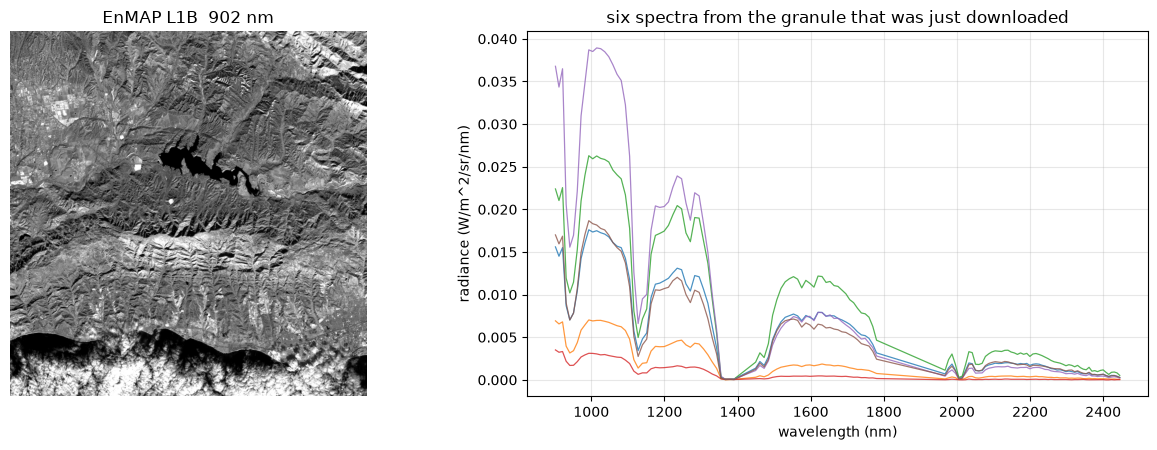

In [37]:
if ds is not None:
    var = hp.main_var(ds)
    cube, wl = ds[var], ds.wavelength.values
    band = int(np.nanargmin(np.abs(wl - 660)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    img = cube.isel(wavelength=band).values
    finite = np.isfinite(img)
    vmin, vmax = np.nanpercentile(img[finite], (2, 98)) if finite.any() else (0, 1)
    axes[0].imshow(img, vmin=vmin, vmax=vmax, cmap="gray")
    axes[0].set_title(f"{ds.attrs['sensor']} {ds.attrs['level']}  {wl[band]:.0f} nm")
    axes[0].axis("off")

    ys, xs = np.where(finite)
    for y, x in zip(ys[::max(1, len(ys) // 6)][:6], xs[::max(1, len(xs) // 6)][:6]):
        axes[1].plot(wl, cube[y, x].values, lw=0.9, alpha=0.8)
    axes[1].set_xlabel("wavelength (nm)")
    axes[1].set_ylabel(f"{var} ({ds[var].attrs.get('units', '')})")
    axes[1].set_title("six spectra from the granule that was just downloaded")
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## What this notebook covered

| Part | Function | What it showed |
|---|---|---|
| 1 | `hp.archive.describe`, `.COLLECTIONS`, `.ELSEWHERE`, `.resolve` | which archives exist, and the sensor spellings that reach them |
| 1 | `hp.search` | every parameter, and the backend-specific extras |
| 1 | `Results`, `Granule` | what a result carries, and the fields it honestly leaves empty |
| 1 | `hp.search_map`, `Map.show`, `Map.fit` | the map, and every button as a method |
| 1 | `hp.download` | every parameter, and the credential each archive wants |
| **2** | **all thirteen collections** | **search, map, select, download - the same three steps over one area, so the differences are the instruments' and not the questions'** |
| 3 | the refusals | eight ways to be told no, each naming its reason |
| 3 | `hp.open` | the file arrives ready for the reader with no translation |

### To fetch more than the default

Three knobs in step 0, in increasing order of how much disk they cost:

```python
DOWNLOAD[("EMIT", "L2A")] = True      # one collection instead of PACE L2

for pair, coll in hp.archive.COLLECTIONS.items():
    DOWNLOAD[pair] = coll.backend == "cmr"     # every collection you have a login for

TAKE = "all"                          # every hit, not just the first of PICK's order
```

`TAKE = "all"` with `COUNT = 8` is 34.5 GB for EMIT L2A alone and roughly 200 GB across
all thirteen, so `MAX_GB = 10` refuses it and prints the number it refused:

```
chosen (smallest, take=all): 8 of 8, 34.5 GB
         34.5 GB is over MAX_GB=10 - nothing fetched. Raise MAX_GB, or lower TAKE
```

Raise it deliberately rather than discover it afterwards.

### Where to go next

* `emit_tutorial.ipynb` - the full chain on a granule like these: atmospheric correction,
  BRDF normalisation, quality flags, export;
* `neon_tutorial.ipynb` - what to do with the flightlines `hp.files` lists;
* `enmap_tutorial.ipynb`, `desis_tutorial.ipynb` - the DLR scenes found above;
* `aviris3_tutorial.ipynb`, `aviris5_tutorial.ipynb` - the airborne flight lines, where
  topographic correction and FlexBRDF come in.